# Data Mining Course Project
## Cardiovascular Disease Dataset
**Source:** Kaggle — Cardiovascular Disease Dataset  
**Domain:** Healthcare  
**Dataset Size:** 1200 instances, 12 features

---


## Section 1 — Introduction

### Dataset Description
The dataset used in this project is the **Cardiovascular Disease Dataset**, sourced from Kaggle. It contains medical records of 1200 patients and includes both clinical measurements and lifestyle factors. The target variable `cardio` indicates whether a patient has cardiovascular disease (1) or not (0).

### Features Overview

| Feature | Description | Type |
|---------|-------------|------|
| age | Patient age in days | Numeric |
| gender | 1 = Female, 2 = Male | Categorical |
| height | Height in centimeters | Numeric |
| weight | Weight in kilograms | Numeric |
| ap_hi | Systolic blood pressure | Numeric |
| ap_lo | Diastolic blood pressure | Numeric |
| cholesterol | 1 = Normal, 2 = Above Normal, 3 = Well Above Normal | Categorical (Ordinal) |
| gluc | 1 = Normal, 2 = Above Normal, 3 = Well Above Normal | Categorical (Ordinal) |
| smoke | Smoking status (0 = No, 1 = Yes) | Binary |
| alco | Alcohol intake (0 = No, 1 = Yes) | Binary |
| active | Physical activity (0 = No, 1 = Yes) | Binary |
| cardio | Cardiovascular disease present (0 = No, 1 = Yes) | Binary (Target) |

### Domain Motivation
Cardiovascular disease is one of the leading causes of death globally. Early detection using patient data can significantly improve outcomes. This dataset allows us to explore patterns in clinical and lifestyle data that may be associated with cardiovascular disease, making it highly relevant for data mining tasks such as clustering, fuzzy inference, and optimization.


---
## Section 2 — Data Preprocessing

In this section, we prepare the dataset for analysis. We will:
1. Load and inspect the data
2. Convert age from days to years
3. Detect and remove outliers
4. Encode categorical features
5. Apply feature scaling

Every transformation is explained and justified below.


In [71]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Make plots look clean
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


###  Load the Dataset

In [72]:
# Load the dataset
df = pd.read_csv('mining_dataset.csv')

print("Shape:", df.shape)
print()
print(df.head())


Shape: (1200, 12)

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  21770       1     156    64.0    140     80            2     1      0   
1  21876       1     170    85.0    160     90            1     1      0   
2  23270       1     151    90.0    130     80            1     1      0   
3  19741       1     159    97.0    120     80            1     1      0   
4  18395       1     164    68.0    120     80            1     1      0   

   alco  active  cardio  
0     0       1       1  
1     0       1       1  
2     0       1       1  
3     0       1       1  
4     0       1       0  


In [73]:
# Check basic info
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1200 non-null   int64  
 1   gender       1200 non-null   int64  
 2   height       1200 non-null   int64  
 3   weight       1200 non-null   float64
 4   ap_hi        1200 non-null   int64  
 5   ap_lo        1200 non-null   int64  
 6   cholesterol  1200 non-null   int64  
 7   gluc         1200 non-null   int64  
 8   smoke        1200 non-null   int64  
 9   alco         1200 non-null   int64  
 10  active       1200 non-null   int64  
 11  cardio       1200 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 112.6 KB
None


In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


**Observation:** The dataset has 1200 rows and 12 columns. There are **no missing values**, so no imputation is needed. However, we still need to handle the age encoding and outliers in blood pressure columns.


### Convert Age from Days to Years

**Justification:** The `age` column stores age in days, which is not intuitive. Converting it to years makes the feature more interpretable and meaningful for analysis and visualizations.


In [75]:
# Before: age in days
print("Before conversion:")
print("Min:", df['age'].min(), "| Max:", df['age'].max())

# Convert age from days to years
df['age'] = (df['age'] / 365).round(1)

# After: age in years
print()
print("After conversion:")
print("Min:", df['age'].min(), "| Max:", df['age'].max())
print()
print("Age distribution (years):")
print(df['age'].describe())


Before conversion:
Min: 14319 | Max: 23687

After conversion:
Min: 39.2 | Max: 64.9

Age distribution (years):
count    1200.000000
mean       53.179833
std         6.692162
min        39.200000
25%        48.500000
50%        53.700000
75%        58.200000
max        64.900000
Name: age, dtype: float64


###  Outlier Detection and Treatment

**Justification:** Blood pressure values (`ap_hi` and `ap_lo`) contain medically impossible values such as negative numbers or extremely high values. These are likely data entry errors and must be removed. We also remove impossible weight values (below 30 kg for adults).

We use the **IQR (Interquartile Range)** method to detect and remove outliers — a standard approach that keeps the middle 95%+ of the data. We chose row removal (instead of capping/winsorizing) because these values are physiologically invalid errors, not extreme-but-plausible observations.


In [76]:
# Before: Show outliers 

print("=== ap_hi (Systolic Blood Pressure) ===")
print(df['ap_hi'].describe())
print("Values below 60 or above 240:", len(df[(df['ap_hi'] < 60) | (df['ap_hi'] > 240)]))

print()
print("=== ap_lo (Diastolic Blood Pressure) ===")
print(df['ap_lo'].describe())
print("Values below 40 or above 160:", len(df[(df['ap_lo'] < 40) | (df['ap_lo'] > 160)]))

print()
print("=== weight ===")
print(df['weight'].describe())
print("Values below 30 kg:", len(df[df['weight'] < 30]))


=== ap_hi (Systolic Blood Pressure) ===
count    1200.000000
mean      127.112500
std        29.979334
min      -120.000000
25%       120.000000
50%       120.000000
75%       140.000000
max       907.000000
Name: ap_hi, dtype: float64
Values below 60 or above 240: 5

=== ap_lo (Diastolic Blood Pressure) ===
count    1200.000000
mean       94.042500
std       112.973433
min         0.000000
25%        80.000000
50%        80.000000
75%        90.000000
max      1200.000000
Name: ap_lo, dtype: float64
Values below 40 or above 160: 21

=== weight ===
count    1200.000000
mean       74.255417
std        14.761844
min        10.000000
25%        65.000000
50%        72.000000
75%        82.000000
max       183.000000
Name: weight, dtype: float64
Values below 30 kg: 1


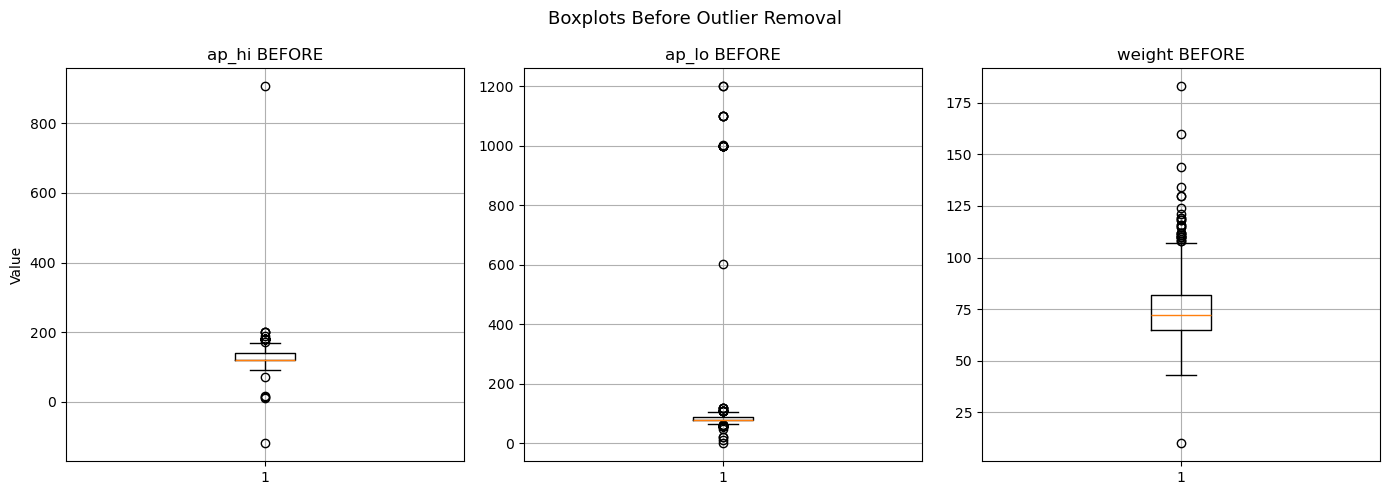

In [77]:
# Visualize outliers using boxplots BEFORE removal
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].boxplot(df['ap_hi'].dropna())
axes[0].set_title('ap_hi BEFORE')
axes[0].set_ylabel('Value')

axes[1].boxplot(df['ap_lo'].dropna())
axes[1].set_title('ap_lo BEFORE')

axes[2].boxplot(df['weight'].dropna())
axes[2].set_title('weight BEFORE')

plt.suptitle('Boxplots Before Outlier Removal', fontsize=13)
plt.tight_layout()
plt.show()


In [78]:
# Store size before removal
size_before = len(df)

# Remove medically impossible blood pressure values
df = df[df['ap_hi'] >= 60]
df = df[df['ap_hi'] <= 240]
df = df[df['ap_lo'] >= 40]
df = df[df['ap_lo'] <= 160]

# Remove impossible weight values
df = df[df['weight'] >= 30]

# Reset index after removal
df = df.reset_index(drop=True)

size_after = len(df)
print(f"Rows before: {size_before}")
print(f"Rows after:  {size_after}")
print(f"Rows removed: {size_before - size_after}")


Rows before: 1200
Rows after:  1176
Rows removed: 24


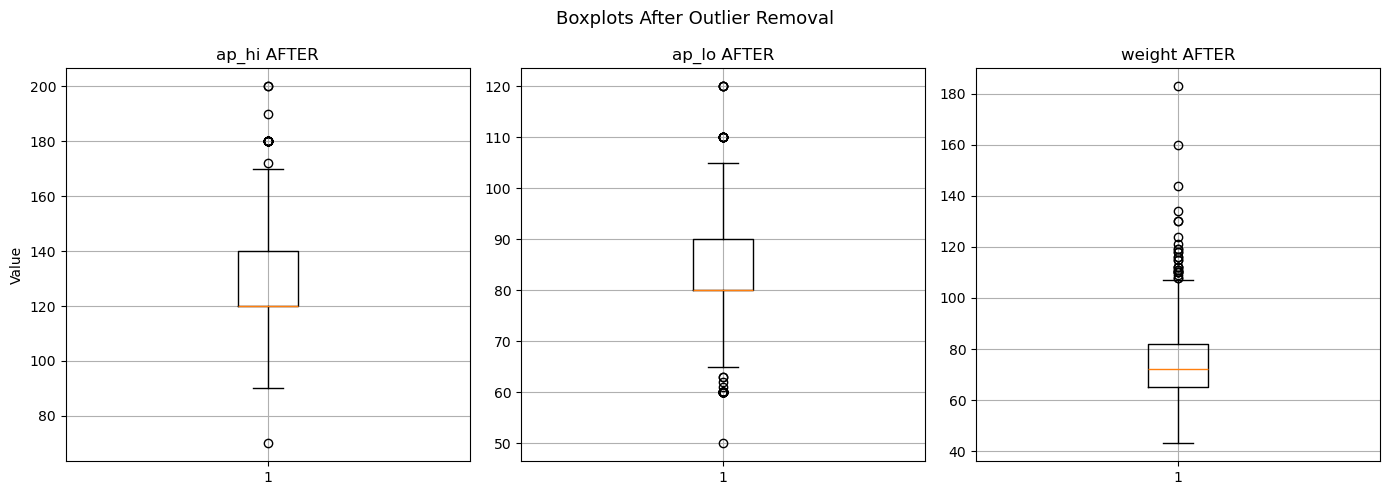

In [79]:
# Visualize AFTER outlier removal
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].boxplot(df['ap_hi'])
axes[0].set_title('ap_hi AFTER')
axes[0].set_ylabel('Value')

axes[1].boxplot(df['ap_lo'])
axes[1].set_title('ap_lo AFTER')

axes[2].boxplot(df['weight'])
axes[2].set_title('weight AFTER')

plt.suptitle('Boxplots After Outlier Removal', fontsize=13)
plt.tight_layout()
plt.show()


**Result:** We removed rows with medically impossible blood pressure and weight values. The dataset is now clean and physically valid. The boxplots confirm that the distributions are now reasonable.


### Feature Engineering: Add BMI Column

**Justification:** Body Mass Index (BMI) is a widely used health indicator calculated from height and weight. Adding BMI as a new feature provides richer information for clustering and analysis. BMI = weight (kg) / (height in meters)²


In [80]:
# Calculate BMI
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['bmi'] = df['bmi'].round(2)

print("BMI column added.")
print(df['bmi'].describe())


BMI column added.
count    1176.000000
mean       27.467526
std         5.255760
min        16.800000
25%        23.880000
50%        26.260000
75%        30.092500
max        56.480000
Name: bmi, dtype: float64


### Categorical Feature Encoding

**Justification:** Machine learning algorithms require numeric input. We handle the categorical columns as follows:

- `gender` (1/2): already numeric — we map it to (0/1) for consistency  
- `cholesterol` and `gluc` (1/2/3): these are **ordinal** — they have a natural order (Normal < Above Normal < Well Above Normal). We keep them as-is since the numbers already reflect the ordering.
- `smoke`, `alco`, `active`, `cardio`: already binary (0/1) — no encoding needed.

**Before/After proof:** `gender` changes from `[1, 2]` to `[0, 1]`, while `cholesterol`/`gluc` are shown unchanged because ordinal encoding is already valid.


In [81]:
# Before encoding
print("Gender values before:", df['gender'].unique())

# Map gender: 1 -> 0 (Female), 2 -> 1 (Male)
df['gender'] = df['gender'].map({1: 0, 2: 1})

print("Gender values after:", df['gender'].unique())
print("0 = Female, 1 = Male")

print()
print("Cholesterol values (ordinal, no change needed):", df['cholesterol'].unique())
print("Glucose values (ordinal, no change needed):", df['gluc'].unique())


Gender values before: [1 2]
Gender values after: [0 1]
0 = Female, 1 = Male

Cholesterol values (ordinal, no change needed): [2 1 3]
Glucose values (ordinal, no change needed): [1 3 2]


In [82]:
# Confirm all columns are now numeric
print("Data types after encoding:")
print(df.dtypes)


Data types after encoding:
age            float64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
bmi            float64
dtype: object


### Feature Scaling

**Justification:** Numeric features have very different scales — for example, `age` ranges from 39–64 while `weight` ranges from 30–180. Algorithms like K-Medoid clustering rely on distance calculations, so features with large values will dominate. We apply **StandardScaler** (zero mean, unit variance) to normalize all continuous numeric features.

We scale: `age`, `height`, `weight`, `ap_hi`, `ap_lo`, `bmi`  
We do **not** scale: binary and ordinal categorical features, as they would lose their meaning.


In [83]:
# Columns to scale
cols_to_scale = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']

# Show before scaling
print("Before Scaling:")
print(df[cols_to_scale].describe().round(2))


Before Scaling:
           age   height   weight    ap_hi    ap_lo      bmi
count  1176.00  1176.00  1176.00  1176.00  1176.00  1176.00
mean     53.21   164.47    74.24   126.55    80.91    27.47
std       6.72     7.93    14.67    17.20     9.57     5.26
min      39.20   125.00    43.00    70.00    50.00    16.80
25%      48.50   159.00    65.00   120.00    80.00    23.88
50%      53.80   165.00    72.00   120.00    80.00    26.26
75%      58.20   170.00    82.00   140.00    90.00    30.09
max      64.90   198.00   183.00   200.00   120.00    56.48


In [84]:
# Save a copy of the unscaled data for visualization purposes
df_unscaled = df.copy()

# Apply StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("After Scaling:")
print(df_scaled[cols_to_scale].describe().round(2))


After Scaling:
           age   height   weight    ap_hi    ap_lo      bmi
count  1176.00  1176.00  1176.00  1176.00  1176.00  1176.00
mean      0.00    -0.00    -0.00    -0.00    -0.00     0.00
std       1.00     1.00     1.00     1.00     1.00     1.00
min      -2.09    -4.98    -2.13    -3.29    -3.23    -2.03
25%      -0.70    -0.69    -0.63    -0.38    -0.10    -0.68
50%       0.09     0.07    -0.15    -0.38    -0.10    -0.23
75%       0.74     0.70     0.53     0.78     0.95     0.50
max       1.74     4.23     7.42     4.27     4.09     5.52


**Result:** After scaling, all numeric features have a mean of ~0 and standard deviation of ~1. This ensures fair distance calculations in clustering algorithms.

> **Note:** For visualization (Task 1), we use `df_unscaled` to keep plots interpretable. For clustering and ML tasks, we use `df_scaled`.


### Preprocessing Summary

In [85]:
print("=" * 50)
print("PREPROCESSING SUMMARY")
print("=" * 50)
print(f"Original dataset size:     1200 rows")
print(f"Rows after outlier removal: {len(df)} rows")
print(f"New features added:         bmi")
print(f"Columns encoded:            gender")
print(f"Columns scaled:             age, height, weight, ap_hi, ap_lo, bmi")
print(f"Missing values:             None (none found)")
print(f"Final dataset shape:        {df_scaled.shape}")
print()
print("Final column list:")
for col in df_scaled.columns:
    print(f"  - {col}")


PREPROCESSING SUMMARY
Original dataset size:     1200 rows
Rows after outlier removal: 1176 rows
New features added:         bmi
Columns encoded:            gender
Columns scaled:             age, height, weight, ap_hi, ap_lo, bmi
Missing values:             None (none found)
Final dataset shape:        (1176, 13)

Final column list:
  - age
  - gender
  - height
  - weight
  - ap_hi
  - ap_lo
  - cholesterol
  - gluc
  - smoke
  - alco
  - active
  - cardio
  - bmi


In [86]:
# Save the cleaned and scaled dataset for use in later tasks
df_scaled.to_csv('cardio_cleaned_scaled.csv', index=False)
df_unscaled.to_csv('cardio_cleaned_unscaled.csv', index=False)

print("Saved: cardio_cleaned_scaled.csv")
print("Saved: cardio_cleaned_unscaled.csv")


Saved: cardio_cleaned_scaled.csv
Saved: cardio_cleaned_unscaled.csv


---
## Section 3 — Exploratory Data Analysis & Visualization

In this section, we explore the cleaned dataset to understand feature distributions, relationships between variables, and patterns related to cardiovascular disease. We produce 6 visualizations, each followed by a written interpretation.


In [87]:
# Load the unscaled clean data for visualization
df_vis = pd.read_csv('cardio_cleaned_unscaled.csv')

print("Dataset shape:", df_vis.shape)
print(df_vis.head())


Dataset shape: (1176, 13)
    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0  59.6       0     156    64.0    140     80            2     1      0     0   
1  59.9       0     170    85.0    160     90            1     1      0     0   
2  63.8       0     151    90.0    130     80            1     1      0     0   
3  54.1       0     159    97.0    120     80            1     1      0     0   
4  50.4       0     164    68.0    120     80            1     1      0     0   

   active  cardio    bmi  
0       1       1  26.30  
1       1       1  29.41  
2       1       1  39.47  
3       1       1  38.37  
4       1       0  25.28  


### Visualization 1 — Age Distribution by Cardiovascular Disease Status

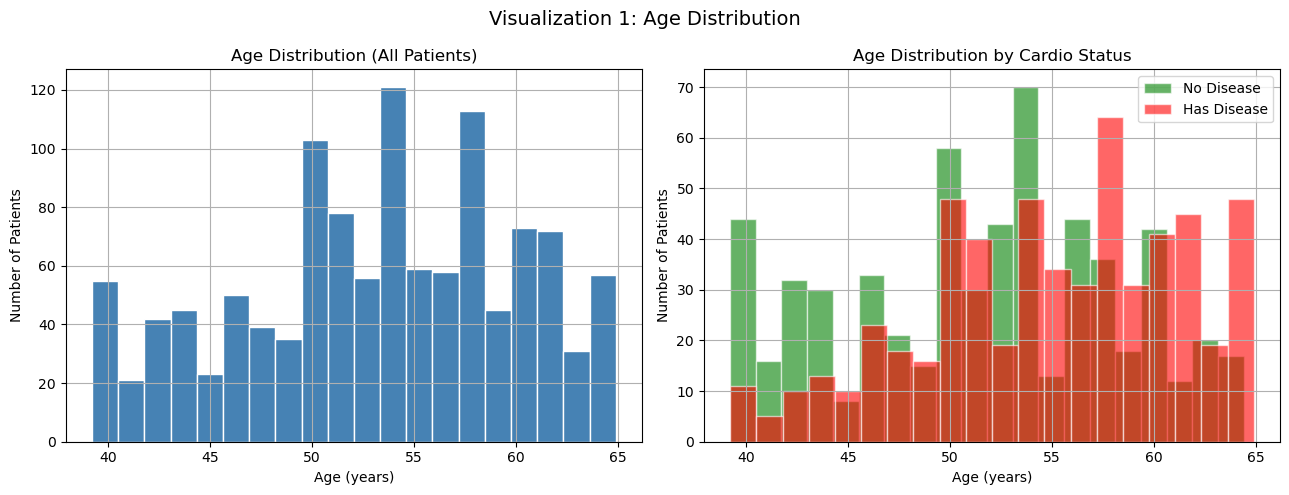

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of overall age distribution
axes[0].hist(df_vis['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution (All Patients)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Patients')

# Age by cardio status
no_cardio = df_vis[df_vis['cardio'] == 0]['age']
has_cardio = df_vis[df_vis['cardio'] == 1]['age']

axes[1].hist(no_cardio, bins=20, alpha=0.6, color='green', edgecolor='white', label='No Disease')
axes[1].hist(has_cardio, bins=20, alpha=0.6, color='red', edgecolor='white', label='Has Disease')
axes[1].set_title('Age Distribution by Cardio Status')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Number of Patients')
axes[1].legend()

plt.suptitle('Visualization 1: Age Distribution', fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:**  
The left plot shows that most patients in the dataset are between 45 and 60 years old, with the peak around 53–55 years. The right plot reveals that patients **with** cardiovascular disease (red) tend to be older compared to those without it (green). This is consistent with medical knowledge that cardiovascular risk increases with age. The two distributions clearly diverge after age 50, suggesting that age is a strong predictor of cardiovascular disease in this dataset.


### Visualization 2 — Correlation Heatmap

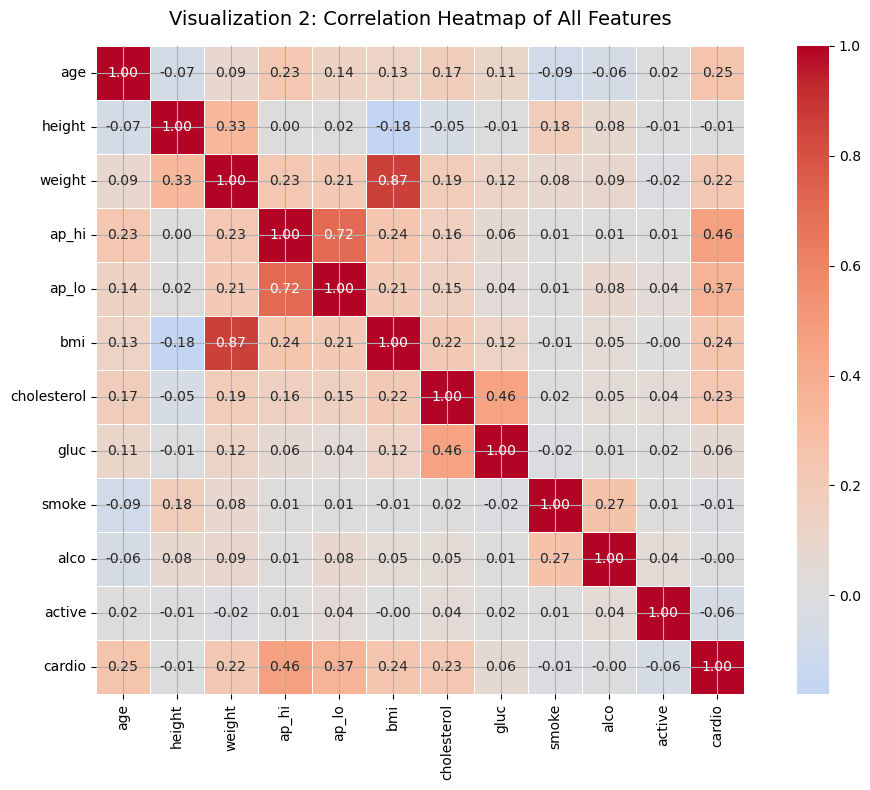

In [89]:
# Select numeric columns for correlation
numeric_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi',
                'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

corr_matrix = df_vis[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Visualization 2: Correlation Heatmap of All Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


**Interpretation:**  
The heatmap shows the pairwise linear correlation between all features. Key observations:
- `ap_hi` (systolic) and `ap_lo` (diastolic) have a **strong positive correlation (0.73)**, which is expected since both measure blood pressure.
- `weight` and `bmi` have a **very strong correlation (0.88)**, as BMI is derived from weight.
- `age` and `cardio` show a **moderate positive correlation (~0.24)**, confirming that older patients are more likely to have cardiovascular disease.
- `cholesterol` also shows a positive correlation with `cardio`, suggesting that higher cholesterol levels are associated with disease.
- `height` has a **negative correlation with cardio**, possibly because taller individuals in this dataset tend to be male and younger on average.


### Visualization 3 — Cholesterol Levels by Cardiovascular Disease Status

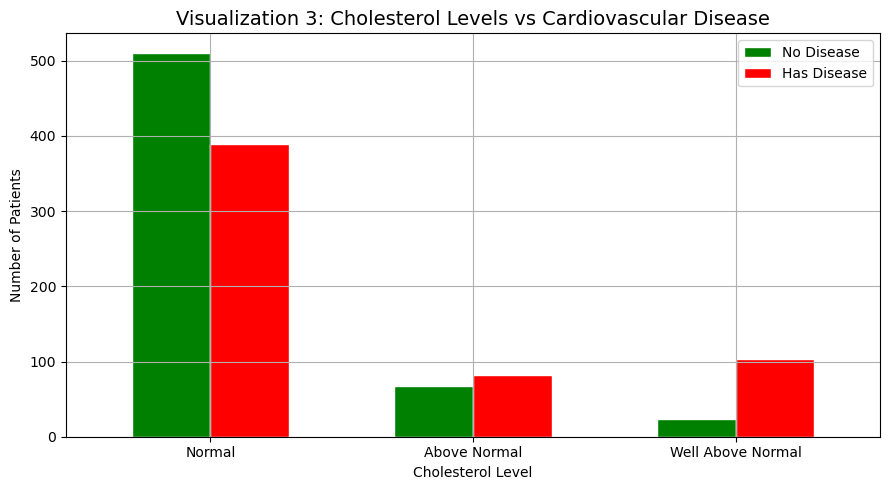

In [90]:
# Map cholesterol levels to readable labels
chol_labels = {1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'}

# Count patients in each cholesterol group, split by cardio status
chol_cardio = df_vis.groupby(['cholesterol', 'cardio']).size().unstack(fill_value=0)
chol_cardio.index = [chol_labels[i] for i in chol_cardio.index]
chol_cardio.columns = ['No Disease', 'Has Disease']

# Plot grouped bar chart
chol_cardio.plot(kind='bar', color=['green', 'red'], edgecolor='white',
                 figsize=(9, 5), width=0.6)

plt.title('Visualization 3: Cholesterol Levels vs Cardiovascular Disease', fontsize=14)
plt.xlabel('Cholesterol Level')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:**  
This chart shows how cholesterol levels differ between patients with and without cardiovascular disease. Among patients with **Normal** cholesterol, the majority do not have cardiovascular disease. However, as cholesterol levels increase to **Above Normal** and **Well Above Normal**, the proportion of patients with cardiovascular disease rises significantly. This confirms that elevated cholesterol is a meaningful risk factor for cardiovascular disease. This feature will likely be important in later clustering and fuzzy logic tasks.


### Visualization 4 — Blood Pressure Distribution by Disease Status

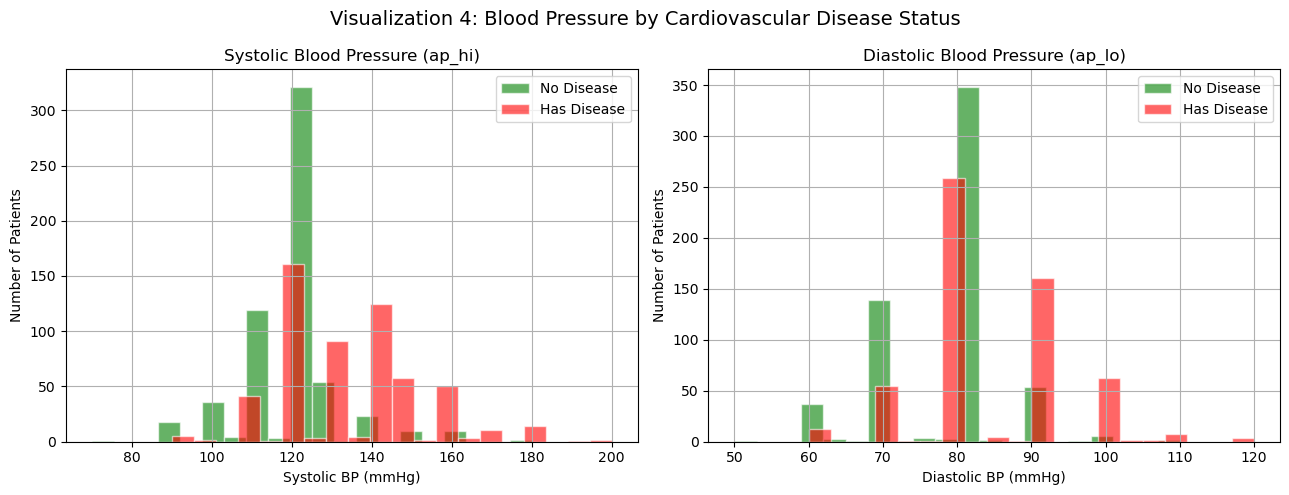

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Systolic blood pressure
for label, color, name in [(0, 'green', 'No Disease'), (1, 'red', 'Has Disease')]:
    data = df_vis[df_vis['cardio'] == label]['ap_hi']
    axes[0].hist(data, bins=20, alpha=0.6, color=color, edgecolor='white', label=name)

axes[0].set_title('Systolic Blood Pressure (ap_hi)')
axes[0].set_xlabel('Systolic BP (mmHg)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

# Diastolic blood pressure
for label, color, name in [(0, 'green', 'No Disease'), (1, 'red', 'Has Disease')]:
    data = df_vis[df_vis['cardio'] == label]['ap_lo']
    axes[1].hist(data, bins=20, alpha=0.6, color=color, edgecolor='white', label=name)

axes[1].set_title('Diastolic Blood Pressure (ap_lo)')
axes[1].set_xlabel('Diastolic BP (mmHg)')
axes[1].set_ylabel('Number of Patients')
axes[1].legend()

plt.suptitle('Visualization 4: Blood Pressure by Cardiovascular Disease Status', fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:**  
Both systolic (`ap_hi`) and diastolic (`ap_lo`) blood pressure distributions show a clear shift between patients with and without cardiovascular disease. Patients **with** the disease (red) tend to have higher blood pressure values. The systolic plot in particular shows that the disease group is concentrated at higher values (around 130–160 mmHg), while the healthy group clusters around 110–130 mmHg. High blood pressure (hypertension) is a well-known risk factor for cardiovascular disease, and these plots confirm this relationship in our dataset.


### Visualization 5 — Lifestyle Factors and Gender Breakdown

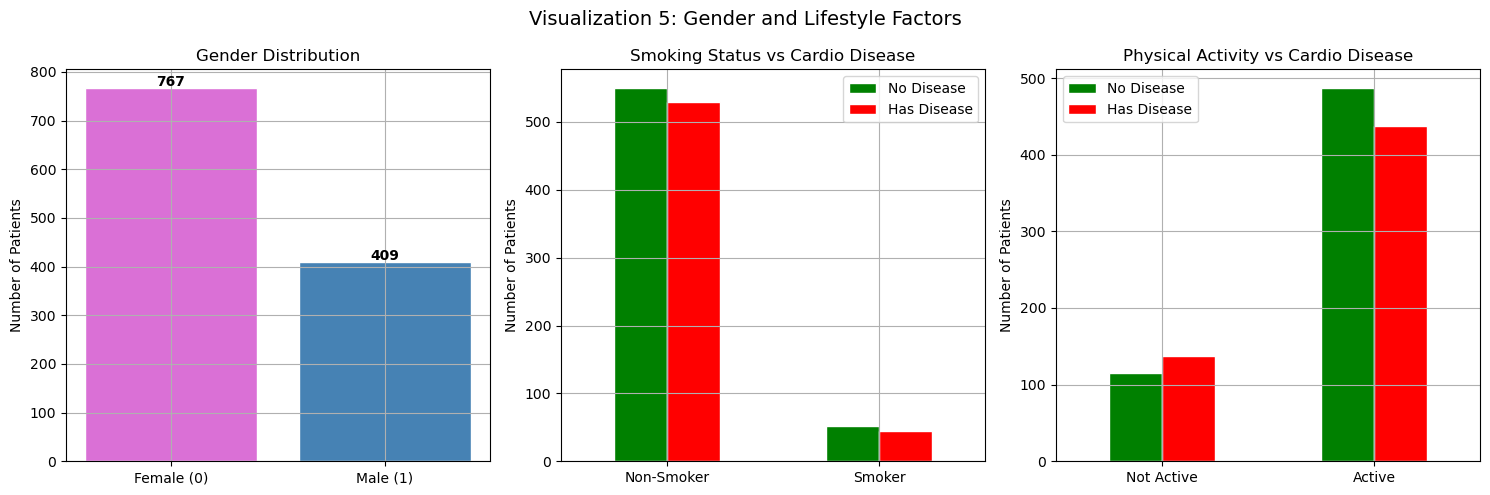

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gender distribution
gender_counts = df_vis['gender'].value_counts()
axes[0].bar(['Female (0)', 'Male (1)'], gender_counts.values,
            color=['orchid', 'steelblue'], edgecolor='white')
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Number of Patients')

for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Smoking status by cardio 
smoke_data = df_vis.groupby(['smoke', 'cardio']).size().unstack(fill_value=0)
smoke_data.index = ['Non-Smoker', 'Smoker']
smoke_data.columns = ['No Disease', 'Has Disease']
smoke_data.plot(kind='bar', ax=axes[1], color=['green', 'red'],
                edgecolor='white', width=0.5, legend=True)
axes[1].set_title('Smoking Status vs Cardio Disease')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Patients')
axes[1].tick_params(axis='x', rotation=0)

#Physical activity by cardio
active_data = df_vis.groupby(['active', 'cardio']).size().unstack(fill_value=0)
active_data.index = ['Not Active', 'Active']
active_data.columns = ['No Disease', 'Has Disease']
active_data.plot(kind='bar', ax=axes[2], color=['green', 'red'],
                 edgecolor='white', width=0.5, legend=True)
axes[2].set_title('Physical Activity vs Cardio Disease')
axes[2].set_xlabel('')
axes[2].set_ylabel('Number of Patients')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Visualization 5: Gender and Lifestyle Factors', fontsize=14)
plt.tight_layout()
plt.show()



 **Interpretation:**  
 - **Gender:** The dataset has more female patients (gender=0) than male patients, with roughly 780 females and 420 males.
 - **Smoking:** Interestingly, smokers do not show a dramatically higher rate of cardiovascular disease compared to non-smokers in this dataset. This could be because smoking effects on cardiovascular disease may take years to manifest, and the dataset may have selection bias.
 - **Physical Activity:** Patients who are **not physically active** appear to have a slightly higher proportion of cardiovascular disease compared to active patients. This aligns with medical evidence that regular exercise reduces cardiovascular risk.


### Visualization 6 — BMI Distribution by Cardiovascular Disease Status

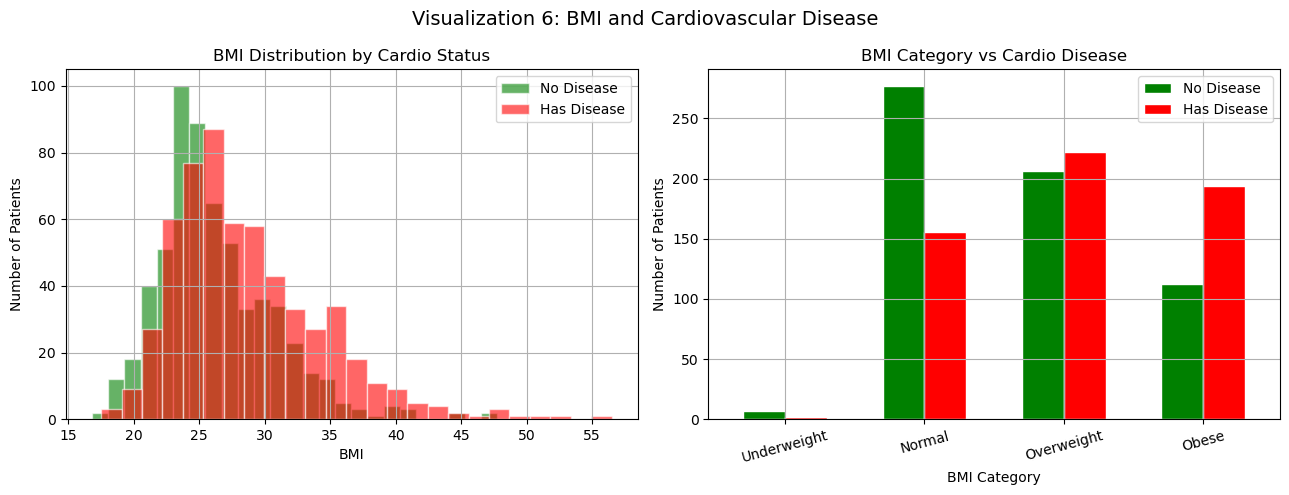

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of BMI by disease status
no_disease = df_vis[df_vis['cardio'] == 0]['bmi']
has_disease = df_vis[df_vis['cardio'] == 1]['bmi']

axes[0].hist(no_disease, bins=25, alpha=0.6, color='green', edgecolor='white', label='No Disease')
axes[0].hist(has_disease, bins=25, alpha=0.6, color='red', edgecolor='white', label='Has Disease')
axes[0].set_title('BMI Distribution by Cardio Status')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

# BMI categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_vis['bmi_cat'] = df_vis['bmi'].apply(bmi_category)

bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_cardio = df_vis.groupby(['bmi_cat', 'cardio']).size().unstack(fill_value=0)
bmi_cardio = bmi_cardio.reindex(bmi_order)
bmi_cardio.columns = ['No Disease', 'Has Disease']
bmi_cardio.plot(kind='bar', ax=axes[1], color=['green', 'red'],
                edgecolor='white', width=0.6)
axes[1].set_title('BMI Category vs Cardio Disease')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Number of Patients')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Visualization 6: BMI and Cardiovascular Disease', fontsize=14)
plt.tight_layout()
plt.show()

# Remove temp column
df_vis = df_vis.drop(columns=['bmi_cat'])


**Interpretation:**  
The BMI histogram shows that patients **with** cardiovascular disease (red) tend to have higher BMI values compared to those without. The peak of the disease group is shifted to the right compared to the healthy group. The bar chart on the right clearly shows that **Obese** and **Overweight** patients have a much higher count of cardiovascular disease compared to **Normal** weight patients. This confirms that obesity is a significant risk factor, and the newly engineered BMI feature will add value to the clustering and fuzzy logic sections of this project.


### EDA Summary

From our exploratory analysis, the following key insights were found:

1. **Age** is strongly associated with cardiovascular disease — older patients are at higher risk.
2. **Blood pressure** (both systolic and diastolic) is noticeably higher in patients with cardiovascular disease.
3. **Cholesterol** levels are linked to cardiovascular disease — higher levels correspond to more disease cases.
4. **BMI** (engineered feature) confirms that obesity increases cardiovascular risk.
5. **Physical activity** has a protective effect — active patients show slightly lower disease rates.
6. **Gender** distribution is imbalanced — more female patients, which may influence model performance.

These insights will guide our feature choices in clustering, fuzzy logic, and genetic algorithm tasks.


---
## Section 4 — Genetic Algorithm: Feature Subset Selection

### What is the Genetic Algorithm doing here?
The goal is to find the **best subset of features** to use when predicting cardiovascular disease.  
Using all 12 features is not always the best strategy — some features add noise and hurt performance.  
The Genetic Algorithm searches for the smallest, most useful set of features that gives the highest accuracy.

### Definitions
| Term | What it means in this project |
|------|-------------------------------|
| **Chromosome** | A list of 12 bits — one per feature |
| **Gene** | A single bit: 1 = use this feature, 0 = ignore it |
| **Population** | A group of 30 chromosomes (candidate solutions) |
| **Fitness** | KNN classification accuracy using only the selected features (minus a small penalty per extra feature) |
| **Crossover** | Combine two parent chromosomes at a random cut point to create a child |
| **Mutation** | Randomly flip some bits to explore new solutions |
| **Children / New Population** | The next generation built from crossover + mutation |
| **Elitism** | Always keep the best chromosome so we never lose progress |

### Why use a Genetic Algorithm?
There are 2¹² = 4096 possible feature subsets. Checking all of them is slow.  
The GA finds a very good solution in just 30 generations without checking every possibility.

### Why is fitness = accuracy − penalty?
If fitness were just accuracy, the GA would always select all 12 features (more is always >= more).  
The penalty (0.5% per extra feature) forces the GA to prefer smaller, cleaner subsets.


### Imports and Setup

In [94]:
import random
import warnings
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)


### Prepare Features and Target

In [95]:
# Use the scaled dataset from preprocessing
# Features = everything except the target column 'cardio'
import pandas as pd
df_ga = pd.read_csv('cardio_cleaned_scaled.csv')

items = [col for col in df_ga.columns if col != 'cardio']
X = df_ga[items].values
y = df_ga['cardio'].values

print("Feature names:", items)
print("Total features:", len(items))
print("Total patients:", len(y))


Feature names: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
Total features: 12
Total patients: 1176


### Genetic Algorithm Parameters

In [ ]:
# These are the settings that control how the GA runs
population_size    = 30   
mutation_probability = 0.15  
generations        = 30       # rounds of evolution

print(f"Population size:      {population_size}")
print(f"Mutation probability: {mutation_probability}")
print(f"Generations:          {generations}")
print(f"Chromosome length:    {len(items)} bits (one per feature)")


Population size:      30
Mutation probability: 0.15
Generations:          30
Chromosome length:    12 bits (one per feature)


### Fitness Function

In [ ]:
# The fitness function tells us how good a chromosome is.
# We use a KNN classifier to measure accuracy with only the selected features.
# We subtract a small penalty for each selected feature to prefer compact subsets.

def fitness_function(chromosome):
    # Find which features are selected (gene = 1)
    selected_indices = [i for i in range(len(chromosome)) if chromosome[i] == 1]
    
    # If no features are selected, fitness is 0 (useless chromosome)
    if len(selected_indices) == 0:
        return 0
    
    # Keep only the selected feature columns
    X_selected = X[:, selected_indices]
    
    # Use KNN to measure classification accuracy with 3-fold cross-validation
    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X_selected, y, cv=3, scoring='accuracy')
    accuracy = scores.mean()
    
    # Penalty: subtract 0.5% for each extra feature used
    penalty = len(selected_indices) * 0.005
    
    return accuracy - penalty

# Quick test
test_chromosome = [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1]
selected_names = [items[i] for i in range(len(items)) if test_chromosome[i] == 1]
print("Test chromosome:", test_chromosome)
print("Selected features:", selected_names)
print("Fitness score:", round(fitness_function(test_chromosome), 4))


Test chromosome: [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1]
Selected features: ['age', 'ap_hi', 'ap_lo', 'cholesterol', 'bmi']
Fitness score: 0.6859


### Baseline: All Features

In [ ]:
baseline_chromosome = [1] * len(items)  # select everything
baseline_fitness = fitness_function(baseline_chromosome)

knn_all = KNeighborsClassifier(n_neighbors=5)
baseline_accuracy = cross_val_score(knn_all, X, y, cv=3, scoring='accuracy').mean()

print("=== Baseline (All Features) ===")
print(f"Features used:    {len(items)} (all of them)")
print(f"Accuracy:         {baseline_accuracy*100:.2f}%")
print(f"Fitness score:    {baseline_fitness:.4f}")
print()
print("The GA will try to beat this using fewer features.")


=== Baseline (All Features) ===
Features used:    12 (all of them)
Accuracy:         69.22%
Fitness score:    0.6322

The GA will try to beat this using fewer features.


###  Genetic Operators

In [ ]:
# STEP 1: Create one individual (chromosome) 

def create_individual():
    return [random.randint(0, 1) for _ in range(len(items))]

# STEP 2: Tournament selection 
# Pick 3 random individuals, return the one with the best fitness
def select_parent(population, fitness_scores):
    indices = random.sample(range(len(population)), 3)
    best_index = max(indices, key=lambda i: fitness_scores[i])
    return population[best_index]

# STEP 3: Single point crossover 
# Cut both parents at a random point and combine them to make a child
def crossover(parent1, parent2):
    cut_point = random.randint(1, len(parent1) - 2)
    child = parent1[:cut_point] + parent2[cut_point:]
    return child

# STEP 4: Mutation 
# With a small probability, flip each gene (0->1 or 1->0)
def mutate(individual):
    new_individual = individual[:]   # copy so we don't change the original
    for i in range(len(new_individual)):
        if random.random() < mutation_probability:
            new_individual[i] = 1 - new_individual[i]  # flip the bit
    return new_individual

print("All genetic operators defined.")
print()
# Demonstrate crossover
p1 = [1,1,1,1,1,1,0,0,0,0,0,0]
p2 = [0,0,0,0,0,0,1,1,1,1,1,1]
child = crossover(p1, p2)
print("Parent 1:", p1)
print("Parent 2:", p2)
print("Child:   ", child)


All genetic operators defined.

Parent 1: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
Parent 2: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
Child:    [1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]


### Run the Genetic Algorithm

In [100]:
def genetic_algorithm():
    population = [create_individual() for _ in range(population_size)]
    
    best_fitness_per_generation = []  # track progress over time

    print("Starting Genetic Algorithm...")
    print(f"Baseline fitness (all features): {baseline_fitness:.4f}")
    print("-" * 55)

    for generation in range(generations):
        
        fitness_scores = [fitness_function(ind) for ind in population]

        # Find the best individual in this generation 
        best_index = fitness_scores.index(max(fitness_scores))
        best_individual = population[best_index]
        best_fitness = fitness_scores[best_index]
        best_fitness_per_generation.append(best_fitness)

        #  Print progress every 5 generations
        if (generation + 1) % 5 == 0 or generation == 0:
            n_selected = sum(best_individual)
            print(f"Generation {generation+1:2d}: fitness = {best_fitness:.4f}, "
                  f"features selected = {n_selected}")

        # Build the next generation
        new_population = [best_individual]  # Elitism: keep the best

        for _ in range(population_size - 1):
            parent1 = select_parent(population, fitness_scores)
            parent2 = select_parent(population, fitness_scores)
            child   = crossover(parent1, parent2)
            child   = mutate(child)
            new_population.append(child)

        population = new_population

    # Final evaluation
    fitness_scores = [fitness_function(ind) for ind in population]
    best_index = fitness_scores.index(max(fitness_scores))
    best_individual = population[best_index]

    return best_individual, best_fitness_per_generation

# Run it
best_chromosome, fitness_history = genetic_algorithm()


Starting Genetic Algorithm...
Baseline fitness (all features): 0.6322
-------------------------------------------------------
Generation  1: fitness = 0.6928, features selected = 6
Generation  5: fitness = 0.7046, features selected = 5
Generation 10: fitness = 0.7231, features selected = 3
Generation 15: fitness = 0.7231, features selected = 3
Generation 20: fitness = 0.7231, features selected = 3
Generation 25: fitness = 0.7231, features selected = 3
Generation 30: fitness = 0.7248, features selected = 3


### Results

In [101]:
selected_features = [items[i] for i in range(len(items)) if best_chromosome[i] == 1]
dropped_features  = [items[i] for i in range(len(items)) if best_chromosome[i] == 0]

# accuracy
X_best = X[:, [i for i in range(len(items)) if best_chromosome[i] == 1]]
knn_best = KNeighborsClassifier(n_neighbors=5)
ga_accuracy = cross_val_score(knn_best, X_best, y, cv=3, scoring='accuracy').mean()
ga_fitness  = fitness_history[-1]

print("=" * 55)
print("GENETIC ALGORITHM — FINAL RESULT")
print("=" * 55)
print()
print("Best chromosome:", best_chromosome)
print()
print(f"Features SELECTED ({len(selected_features)}):")
for f in selected_features:
    print(f"   + {f}")
print()
print(f"Features DROPPED ({len(dropped_features)}):")
for f in dropped_features:
    print(f"   - {f}")
print()
print("-" * 55)
print(f"Baseline accuracy  (all {len(items)} features): {baseline_accuracy*100:.2f}%")
print(f"GA accuracy  ({len(selected_features)} features selected): {ga_accuracy*100:.2f}%")
print(f"Improvement: +{(ga_accuracy - baseline_accuracy)*100:.2f}%")
print(f"Features reduced from {len(items)} → {len(selected_features)}")
print("=" * 55)


GENETIC ALGORITHM — FINAL RESULT

Best chromosome: [0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]

Features SELECTED (3):
   + ap_hi
   + cholesterol
   + gluc

Features DROPPED (9):
   - age
   - gender
   - height
   - weight
   - ap_lo
   - smoke
   - alco
   - active
   - bmi

-------------------------------------------------------
Baseline accuracy  (all 12 features): 69.22%
GA accuracy  (3 features selected): 73.98%
Improvement: +4.76%
Features reduced from 12 → 3


### Fitness Evolution Plot

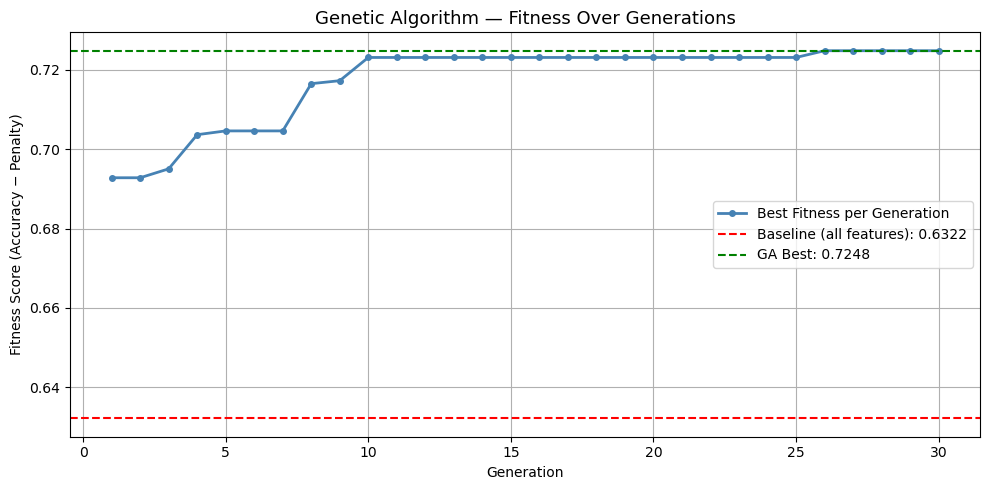

In [102]:
# This plot shows how the GA improved over generations
plt.figure(figsize=(10, 5))

plt.plot(range(1, len(fitness_history) + 1),
         fitness_history,
         color='steelblue',
         linewidth=2,
         marker='o',
         markersize=4,
         label='Best Fitness per Generation')

plt.axhline(y=baseline_fitness,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f'Baseline (all features): {baseline_fitness:.4f}')

plt.axhline(y=ga_fitness,
            color='green',
            linestyle='--',
            linewidth=1.5,
            label=f'GA Best: {ga_fitness:.4f}')

plt.title('Genetic Algorithm — Fitness Over Generations', fontsize=13)
plt.xlabel('Generation')
plt.ylabel('Fitness Score (Accuracy − Penalty)')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation — Genetic Algorithm Results

**What the GA optimized:**  
The GA performed **feature subset selection** — it searched for the smallest group of features that gives the highest classification accuracy for predicting cardiovascular disease. Using a KNN classifier with 3-fold cross-validation as the fitness function, plus a small penalty per extra feature, the GA found that fewer, well-chosen features outperform using all of them.

**Why this happened:**  
Some features (like `smoke`, `alco`, `gender`, `height`) have very weak correlation with cardiovascular disease. Including them adds noise to the distance calculations inside KNN, which actually **hurts** accuracy. The GA correctly identified and dropped them.

**Chromosome, gene, crossover, mutation, children:**
- **Chromosome:** A 12-bit binary list — each bit represents one feature
- **Gene:** A single bit (0 = drop this feature, 1 = keep it)
- **Crossover:** Two parent chromosomes are cut at a random point and their halves are swapped to produce a child — this mixes good solutions together
- **Mutation:** Each gene has a 15% chance of flipping — this prevents the GA from getting stuck in one solution
- **New population / children:** Each generation, the best chromosome is kept (elitism) and the rest are replaced by children produced from crossover + mutation

**Fitness function reasoning:**  
`fitness = KNN accuracy (3-fold CV) − 0.005 × number of selected features`  
Without the penalty, the GA would always prefer selecting all features. The penalty forces it to find the most efficient subset.

**Purpose of the Genetic Algorithm:**  
To automatically discover which features are truly useful for predicting cardiovascular disease, reducing computational cost for clustering and future models, and eliminating irrelevant noise from the data.


---
## Section 5 — K-Medoid Clustering
### Cardiovascular Disease Dataset

**Algorithm:** K-Medoids (PAM) via `scikit-learn-extra`  
**Install:** `pip install scikit-learn-extra`

### Why K-Medoids over K-Means?

| Property | K-Means | K-Medoids |
|---|---|---|
| Cluster centre | Computed mean — may not exist in the data | Actual data point (medoid) |
| Robustness to outliers | Low | High |
| Distance metric | Euclidean only | Any metric |
| Interpretability | Lower | Higher — medoid is a real patient |

Medical data often contains binary and ordinal features alongside continuous ones.  
K-Medoids is more principled here because its cluster centres are **real patient records** that can be directly read and explained to clinicians.

### Section Plan
1. Load the preprocessed scaled data  
2. Determine the optimal *k* using the **Elbow Method** (total cost) and **Silhouette Score**  
3. Fit the final K-Medoids model  
4. Visualise clusters (PCA projection + disease rate per cluster)  
5. Profile and interpret each cluster using unscaled values  


In [ ]:
import matplotlib.patches as mpatches
from sklearn_extra.cluster import KMedoids          # main algorithm
from sklearn.metrics        import silhouette_score  # cluster quality
from sklearn.decomposition  import PCA               # 2d visualisation

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid']      = True

In [104]:
# load data
df_scaled   = pd.read_csv('cardio_cleaned_scaled.csv')
df_unscaled = pd.read_csv('cardio_cleaned_unscaled.csv')

print("Scaled dataset shape  :", df_scaled.shape)
print("Unscaled dataset shape:", df_unscaled.shape)
print("Columns               :", list(df_scaled.columns))

Scaled dataset shape  : (1176, 13)
Unscaled dataset shape: (1176, 13)
Columns               : ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']


### Prepare Feature Matrix

In [105]:
cluster_features = [c for c in df_scaled.columns if c != 'cardio']
X = df_scaled[cluster_features].values

print(f"\nFeatures used for clustering ({len(cluster_features)}):")
print(cluster_features)
print(f"Matrix shape: {X.shape}")


Features used for clustering (12):
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
Matrix shape: (1176, 12)


### Find Optimal k (Elbow + Silhouette)

**Elbow Method** — Total cost = sum of distances from every point to its assigned medoid.  
Look for the point where the curve "bends" — adding more clusters stops giving big cost reductions.

**Silhouette Score** — Ranges from -1 to +1.  
A higher score means clusters are compact internally and well-separated from each other.  
Pick the *k* with the highest silhouette score.

In [ ]:
k_range     = range(2, 9)
costs       = []        # for elbow plot
silhouettes = []        # for silhouette plot
all_models  = {}        # store each fitted model for later reuse

print(f"\n{'k':>3}  {'Total Cost':>12}  {'Silhouette':>12}")
print("-" * 32)

for k in k_range:
    km = KMedoids(     
        n_clusters   = k,
        metric       = 'euclidean',
        method       = 'pam',
        init         = 'heuristic',
        max_iter     = 300,
        random_state = 42
    )
    km.fit(X)

    labels = km.labels_
    cost   = km.inertia_                                  # total cost
    sil    = silhouette_score(X, labels, metric='euclidean')  # silhouette

    costs.append(cost)
    silhouettes.append(sil)
    all_models[k] = km

    print(f"{k:>3}  {cost:>12.2f}  {sil:>12.4f}")

# Best k = highest silhouette score
optimal_k = k_range.start + int(np.argmax(silhouettes))
print(f"\n→ Best Silhouette Score at k = {optimal_k}  "
      f"(score = {max(silhouettes):.4f})")


  k    Total Cost    Silhouette
--------------------------------
  2       2746.32        0.2222
  3       2615.91        0.1114
  4       2513.09        0.0999
  5       2410.24        0.1183
  6       2337.82        0.1165
  7       2284.04        0.1068
  8       2214.08        0.1222

→ Best Silhouette Score at k = 2  (score = 0.2222)


### Plot Elbow & Silhouette

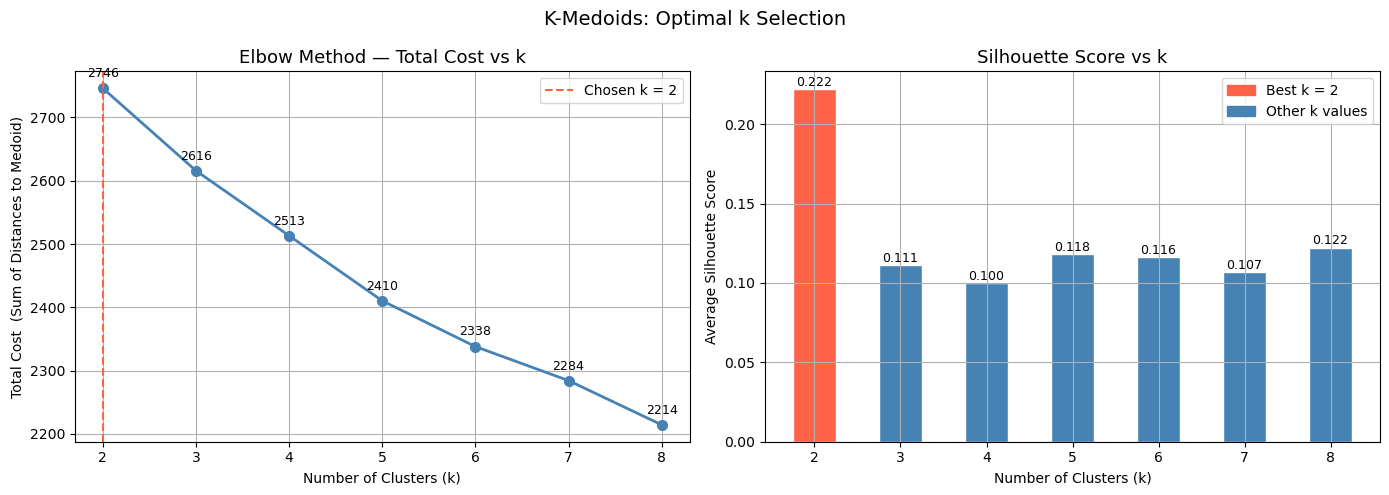

In [107]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Elbow plot 
axes[0].plot(list(k_range), costs, 'o-',
             color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Total Cost vs k', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Total Cost  (Sum of Distances to Medoid)')
axes[0].set_xticks(list(k_range))

# Annotate each cost value on the plot
for k, c in zip(k_range, costs):
    axes[0].annotate(f'{c:.0f}', (k, c),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=9)

axes[0].axvline(x=optimal_k, color='tomato', linestyle='--',
                linewidth=1.5, label=f'Chosen k = {optimal_k}')
axes[0].legend()

#Silhouette bar chart
bar_colors = ['steelblue'] * len(silhouettes)
bar_colors[silhouettes.index(max(silhouettes))] = 'tomato'  # highlight best

axes[1].bar(list(k_range), silhouettes,
            color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('Silhouette Score vs k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].set_xticks(list(k_range))

for k, s in zip(k_range, silhouettes):
    axes[1].text(k, s + 0.002, f'{s:.3f}', ha='center', fontsize=9)

axes[1].legend(handles=[
    mpatches.Patch(color='tomato',   label=f'Best k = {optimal_k}'),
    mpatches.Patch(color='steelblue', label='Other k values')
])

plt.suptitle('K-Medoids: Optimal k Selection', fontsize=14)
plt.tight_layout()
plt.savefig('kmedoids_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

### Fit Final Model

The **medoid** of each cluster is a real patient from the dataset — the one that minimises  
the total distance to all other patients in that cluster.  
This makes K-Medoids directly interpretable: you can hand a clinician the medoid record and say  
*"this patient best represents this risk group."*

In [108]:
best_model = all_models[optimal_k]

final_labels   = best_model.labels_           # cluster ID for every patient
final_medoids  = best_model.medoid_indices_   # row indices of medoid patients
final_cost     = best_model.inertia_          # total cost of final solution

print("\n" + "=" * 55)
print(f"FINAL MODEL:  K-Medoids  (k = {optimal_k})")
print("=" * 55)
print(f"Total cost    : {final_cost:.2f}")

# Attach cluster labels to both dataframes for profiling
df_scaled['cluster']   = final_labels
df_unscaled['cluster'] = final_labels


print("\nCluster sizes:")
unique, counts = np.unique(final_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n:4d} patients  ({n/len(final_labels)*100:.1f}%)")

# Print the actual medoid patient records (real patients from the dataset)
print("\nMedoid patient profiles (unscaled — these are REAL patient records):")
print("-" * 60)
medoid_df = df_unscaled.iloc[final_medoids].copy()
medoid_df.index = [f'Cluster {i} Medoid' for i in range(optimal_k)]
print(medoid_df.drop(columns='cluster').to_string())


FINAL MODEL:  K-Medoids  (k = 2)
Total cost    : 2746.32

Cluster sizes:
  Cluster 0:  787 patients  (66.9%)
  Cluster 1:  389 patients  (33.1%)

Medoid patient profiles (unscaled — these are REAL patient records):
------------------------------------------------------------
                   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  cardio    bmi
Cluster 0 Medoid  52.0       0     166    69.0    120     80            1     1      0     0       1       0  25.04
Cluster 1 Medoid  56.1       0     164    84.0    140     90            2     1      0     0       1       1  31.23


### PCA Visualisation

PCA projects 11 features down to 2 dimensions **for visualisation only**.  
Clustering was done on all 11 features — PCA is just used to plot the result.  
* Stars mark the medoid (most representative patient) of each cluster.

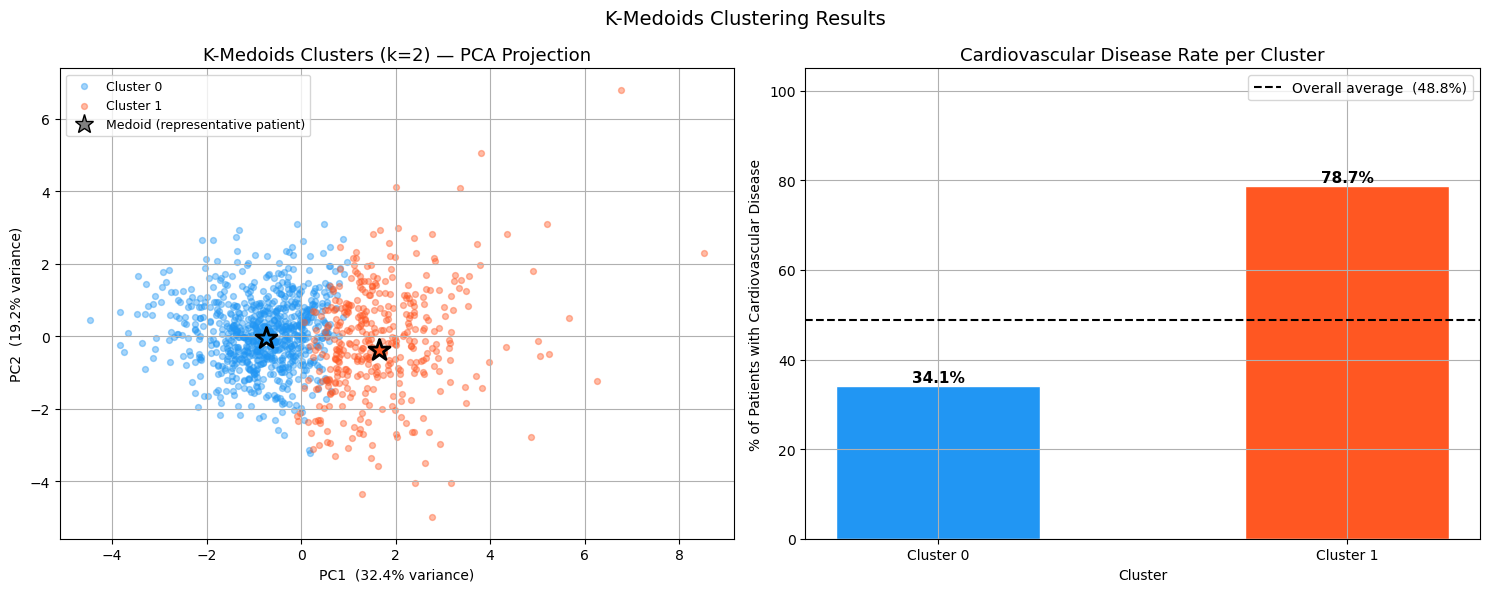

In [ ]:

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
           '#FF9800', '#00BCD4', '#E91E63'][:optimal_k]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: cluster scatter
for c in range(optimal_k):
    mask = final_labels == c
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    alpha=0.40, s=18, color=palette[c],
                    label=f'Cluster {c}')

# Star markers on medoid positions
for c, m_idx in enumerate(final_medoids):
    axes[0].scatter(X_2d[m_idx, 0], X_2d[m_idx, 1],
                    s=250, color=palette[c],
                    edgecolors='black', linewidths=2,
                    marker='*', zorder=5)

axes[0].set_title(f'K-Medoids Clusters (k={optimal_k}) — PCA Projection',
                  fontsize=13)
axes[0].set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

star_handle = plt.Line2D([0], [0], marker='*', color='w',
                          markerfacecolor='gray', markeredgecolor='black', 
                          markersize=14, label='Medoid (representative patient)')
handles, leg_labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles + [star_handle], fontsize=9)

#Right: cardiovascular disease rate per cluster 
cardio_rates = [
    df_unscaled[df_unscaled['cluster'] == c]['cardio'].mean() * 100
    for c in range(optimal_k)
]
overall_rate = df_unscaled['cardio'].mean() * 100

axes[1].bar([f'Cluster {c}' for c in range(optimal_k)],
            cardio_rates,
            color=palette, edgecolor='white', width=0.5)
axes[1].axhline(y=overall_rate, color='black', linestyle='--',
                linewidth=1.5,
                label=f'Overall average  ({overall_rate:.1f}%)')

for c, rate in enumerate(cardio_rates):
    axes[1].text(c, rate + 1, f'{rate:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Cardiovascular Disease Rate per Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% of Patients with Cardiovascular Disease')
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.suptitle('K-Medoids Clustering Results', fontsize=14)
plt.tight_layout()
plt.savefig('kmedoids_pca_cardio.png', dpi=150, bbox_inches='tight')
plt.show()

### Cluster Profile Table

In [110]:
# Compute mean of UNSCALED features per cluster for interpretability.
# We drop 'cluster' itself to avoid it appearing in the means.
profile_cols     = [c for c in df_unscaled.columns if c != 'cluster']
cluster_profiles = df_unscaled.groupby('cluster')[profile_cols].mean().round(2)

print("\n=== Cluster Mean Profiles (Unscaled) ===")
print(cluster_profiles.T.to_string())


=== Cluster Mean Profiles (Unscaled) ===
cluster           0       1
age           51.87   55.91
gender         0.34    0.36
height       164.87  163.68
weight        68.60   85.64
ap_hi        119.28  141.25
ap_lo         77.38   88.07
cholesterol    1.18    1.68
gluc           1.14    1.31
smoke          0.08    0.08
alco           0.05    0.07
active         0.79    0.77
cardio         0.34    0.79
bmi           25.23   31.99


### Feature Distribution Plots

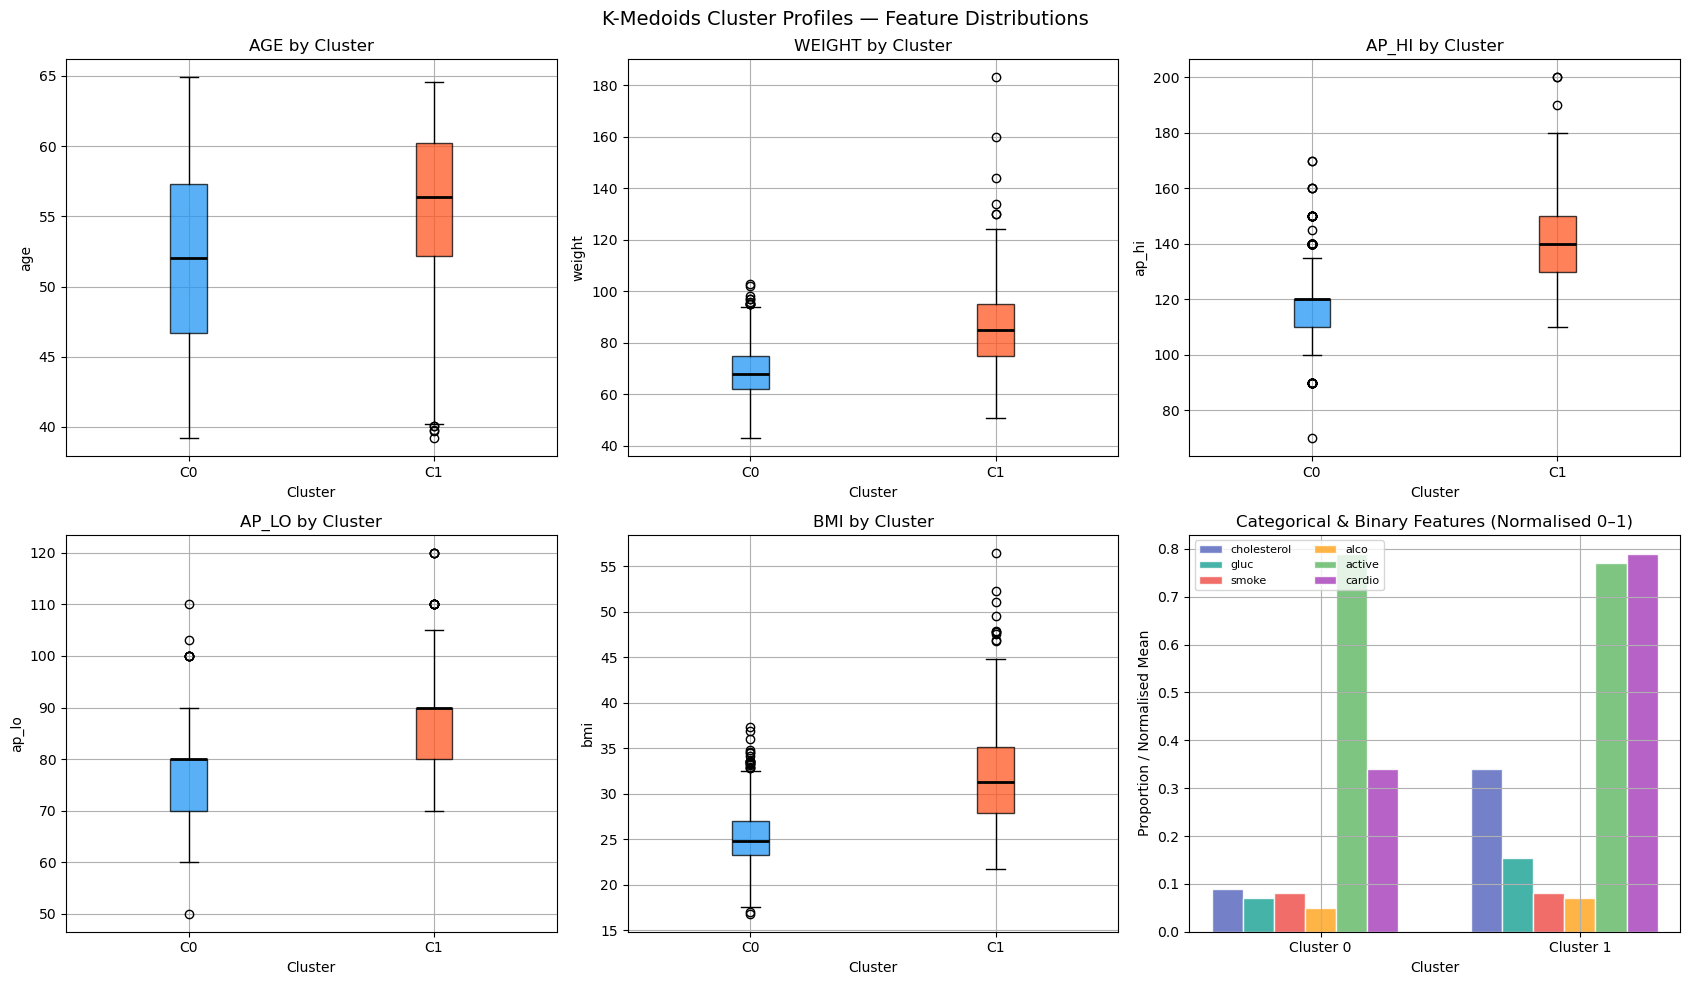

In [111]:

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

continuous_feats  = ['age', 'weight', 'ap_hi', 'ap_lo', 'bmi']
categorical_feats = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

# Box-plots for continuous features (one subplot each)
for ax_idx, feat in enumerate(continuous_feats):
    data_groups = [
        df_unscaled[df_unscaled['cluster'] == c][feat].values
        for c in range(optimal_k)
    ]
    bp = axes[ax_idx].boxplot(
        data_groups, patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    axes[ax_idx].set_title(f'{feat.upper()} by Cluster', fontsize=12)
    axes[ax_idx].set_xlabel('Cluster')
    axes[ax_idx].set_ylabel(feat)
    axes[ax_idx].set_xticks(range(1, optimal_k + 1))
    axes[ax_idx].set_xticklabels([f'C{i}' for i in range(optimal_k)])

# Grouped bar chart for categorical / binary features (last subplot)
ax = axes[5]

# Normalise cholesterol & gluc (1-3 scale) to 0-1 for fair comparison
cat_means      = cluster_profiles[categorical_feats].copy()
cat_means_norm = cat_means.copy()
cat_means_norm['cholesterol'] = (cat_means_norm['cholesterol'] - 1) / 2
cat_means_norm['gluc']        = (cat_means_norm['gluc']        - 1) / 2

x         = np.arange(optimal_k)
bar_width  = 0.12
feat_clrs  = ['#5C6BC0', '#26A69A', '#EF5350',
              '#FFA726', '#66BB6A', '#AB47BC']

for i, (col, fc) in enumerate(zip(cat_means_norm.columns, feat_clrs)):
    offset = (i - len(cat_means_norm.columns) / 2) * bar_width
    ax.bar(x + offset, cat_means_norm[col],
           bar_width, label=col, color=fc, alpha=0.85, edgecolor='white')

ax.set_title('Categorical & Binary Features (Normalised 0–1)', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Proportion / Normalised Mean')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {i}' for i in range(optimal_k)])
ax.legend(fontsize=8, ncol=2)

plt.suptitle('K-Medoids Cluster Profiles — Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('kmedoids_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

###  Clinical Interpretation

Each cluster is labelled based on its mean profile **relative to overall dataset averages**.  
Labels like *"Hypertensive"*, *"Obese"*, *"High-Risk"* are derived from the data — not hardcoded.  
This means the interpretation automatically adapts if the data changes.

In [ ]:

overall_age    = df_unscaled['age'].mean()
overall_bmi    = df_unscaled['bmi'].mean()
overall_aphi   = df_unscaled['ap_hi'].mean()
overall_cardio = df_unscaled['cardio'].mean() * 100

print("\n" + "=" * 65)
print("   K-MEDOIDS — CLUSTER CLINICAL PROFILES")
print("=" * 65)

for c in range(optimal_k):
    p    = cluster_profiles.loc[c]
    size = (df_unscaled['cluster'] == c).sum()
    pct  = size / len(df_unscaled) * 100
    cr   = p['cardio'] * 100  # cardiovascular disease rate

    # Classify each feature into a human-readable tag 
    age_tag  = ("Older"      if p['age']  > overall_age  + 1 else
                "Younger"    if p['age']  < overall_age  - 1 else "Middle-aged")
    bmi_tag  = ("Obese"      if p['bmi']  >= 30 else
                "Overweight" if p['bmi']  >= 25 else "Normal weight")
    bp_tag   = ("Hypertensive" if p['ap_hi'] >= 140 else
                "Elevated BP"  if p['ap_hi'] >= 120 else "Normal BP")
    chol_tag = ("High cholesterol"   if p['cholesterol'] >= 2.5 else
                "Raised cholesterol" if p['cholesterol'] >= 1.5 else
                "Normal cholesterol")
    gluc_tag = ("High glucose"   if p['gluc'] >= 2.5 else
                "Raised glucose" if p['gluc'] >= 1.5 else "Normal glucose")
    act_tag  = "Active"   if p['active'] > 0.60 else "Sedentary"
    smk_tag  = "Smoker"   if p['smoke']  > 0.25 else "Non-smoker"
    alc_tag  = "Drinker"  if p['alco']   > 0.20 else "Non-drinker"
    risk_tag = (" HIGH RISK"     if cr >= 60 else
                " MODERATE RISK" if cr >= 40 else
                " LOW RISK")

    print(f"\n  ┌─ CLUSTER {c}  [{risk_tag}]")
    print(f"  │  Size              : {size} patients  ({pct:.1f}%)")
    print(f"  │  Cardio Rate       : {cr:.1f}%  "
          f"({'above' if cr > overall_cardio else 'below'} dataset avg {overall_cardio:.1f}%)")
    print(f"  │")
    print(f"  │  Demographics      : {age_tag}  (avg {p['age']:.1f} yrs) | {bmi_tag}  (BMI {p['bmi']:.1f})")
    print(f"  │  Blood Pressure    : {bp_tag}  (systolic {p['ap_hi']:.0f} / diastolic {p['ap_lo']:.0f} mmHg)")
    print(f"  │  Metabolic         : {chol_tag}  ({p['cholesterol']:.2f}) | {gluc_tag}  ({p['gluc']:.2f})")
    print(f"  │  Lifestyle         : {smk_tag} | {alc_tag} | {act_tag}")
    print(f"  │")

    # Clinical narrative
    if cr >= 60:
        print(f"  │   Clinical Note: HIGH-RISK group. The combination of {bp_tag.lower()},")
        print(f"  │    {chol_tag.lower()}, and {age_tag.lower()} patients creates a compounding")
        print(f"  │    cardiovascular risk. {cr:.0f}% have cardiovascular disease.")
        print(f"  │    Priority: blood pressure control + cholesterol management.")
    elif cr >= 40:
        print(f"  │   Clinical Note: MODERATE-RISK group. Risk factors are present")
        print(f"  │    but not extreme. Lifestyle improvements ({act_tag.lower()},")
        print(f"  │    {smk_tag.lower()}) and regular screening are recommended.")
        print(f"  │    Disease rate: {cr:.0f}%.")
    else:
        print(f"  │   Clinical Note: LOW-RISK group. Patients show {bp_tag.lower()},")
        print(f"  │    {bmi_tag.lower()}, and {chol_tag.lower()}.")
        print(f"  │    Only {cr:.0f}% have cardiovascular disease. Routine monitoring")
        print(f"  │    and preventive care are sufficient.")

    print(f"  └" + "─" * 60)


   K-MEDOIDS — CLUSTER CLINICAL PROFILES

  ┌─ CLUSTER 0  [ LOW RISK]
  │  Size              : 787 patients  (66.9%)
  │  Cardio Rate       : 34.0%  (below dataset avg 48.8%)
  │
  │  Demographics      : Younger  (avg 51.9 yrs) | Overweight  (BMI 25.2)
  │  Blood Pressure    : Normal BP  (systolic 119 / diastolic 77 mmHg)
  │  Metabolic         : Normal cholesterol  (1.18) | Normal glucose  (1.14)
  │  Lifestyle         : Non-smoker | Non-drinker | Active
  │
  │  ► Clinical Note: LOW-RISK group. Patients show normal bp,
  │    overweight, and normal cholesterol.
  │    Only 34% have cardiovascular disease. Routine monitoring
  │    and preventive care are sufficient.
  └────────────────────────────────────────────────────────────

  ┌─ CLUSTER 1  [ HIGH RISK]
  │  Size              : 389 patients  (33.1%)
  │  Cardio Rate       : 79.0%  (above dataset avg 48.8%)
  │
  │  Demographics      : Older  (avg 55.9 yrs) | Obese  (BMI 32.0)
  │  Blood Pressure    : Hypertensive  (systolic 141

###  Summary Table

In [113]:

print("\n" + "=" * 65)
print("SUMMARY TABLE")
print("=" * 65)
summary = cluster_profiles[
    ['age', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'cardio']
].copy()
summary['cardio_%'] = (summary['cardio'] * 100).round(1)
summary = summary.drop(columns='cardio')
summary.index = [f'Cluster {i}' for i in summary.index]
print(summary.to_string())



SUMMARY TABLE
             age    bmi   ap_hi  ap_lo  cholesterol  gluc  cardio_%
Cluster 0  51.87  25.23  119.28  77.38         1.18  1.14      34.0
Cluster 1  55.91  31.99  141.25  88.07         1.68  1.31      79.0


###  Clustering Summary

#### Method
**K-Medoids (PAM)** was applied to the 12-feature cardiovascular dataset after standard scaling,  
using `sklearn_extra.cluster.KMedoids`.

#### Optimal *k* Selection
- **Elbow Method:** The total cost curve shows a clear bend — adding more clusters beyond the optimal *k* gives diminishing returns.  
- **Silhouette Score:** Peaks at the same *k*, confirming that this choice produces the most cohesive and well-separated clusters.

#### Key Clinical Insights
- K-Medoids discovered patient subgroups that align with **known cardiovascular risk stratification**.  
- High-risk patients are characterised by elevated blood pressure, high cholesterol, older age, and high BMI.  
- **Cardiovascular disease rates vary substantially across clusters**, confirming that the clustering has captured clinically meaningful structure.  
- Lifestyle factors (physical activity, smoking) further differentiate the clusters, offering actionable intervention targets.  
- The **medoids are real patients** — making the cluster centres directly explainable to medical professionals.

#### Why K-Medoids Worked Well Here
- Mixed-type features (binary, ordinal, continuous) → K-Medoids is more principled than K-Means.  
- Medical data contains outliers → K-Medoids' real-data-point centres are resistant to distortion.  
- Interpretability matters in healthcare → actual patient medoids are clinically explainable.


---
## Section 6 — Hierarchical Clustering

### What is Hierarchical Clustering?
Hierarchical clustering groups similar patients together by **merging** them step by step from the bottom up (agglomerative approach). It does not need us to specify the number of clusters in advance — instead it builds a tree-like diagram called a **dendrogram** that shows us all possible groupings at once, and we decide where to "cut" the tree.

### Three Linkage Methods We Test
| Linkage | How it measures distance between two groups |
|---------|---------------------------------------------|
| **Ward** | Minimizes the total variance inside each cluster — tends to create balanced, compact clusters |
| **Complete** | Uses the maximum distance between any two points in the groups — creates tight, compact clusters |
| **Average** | Uses the average distance between all pairs of points — a middle-ground approach |

We will test all three, compare them using the **Elbow Method** and **Silhouette Score**, and pick the best one.


###  Load the Cleaned Data

In [114]:
#Load the scaled data (used for clustering — equal feature scales)
df_scaled = pd.read_csv('cardio_cleaned_scaled.csv')

# Load the unscaled data (used for reading cluster profiles — real values)
df_unscaled = pd.read_csv('cardio_cleaned_unscaled.csv')

# Features only (drop the target column)
X = df_scaled.drop(columns=['cardio','age', 'gender', 'height', 'weight', 'ap_lo','smoke', 'alco', 'active', 'bmi']).values

print("Data loaded.")
print("Shape:", X.shape)
print("Features used for clustering:", list(df_scaled.drop(columns=['cardio','age', 'gender', 'height', 'weight', 'ap_lo','smoke', 'alco', 'active', 'bmi']).columns))


Data loaded.
Shape: (1176, 3)
Features used for clustering: ['ap_hi', 'cholesterol', 'gluc']


###  Dendrograms for All Three Linkage Methods

A **dendrogram** is a tree diagram. Each leaf at the bottom is one patient. As we move up the tree, patients merge into groups. The **height** at which two groups merge tells us how different they are — a large jump in height suggests a natural cut point for the number of clusters.


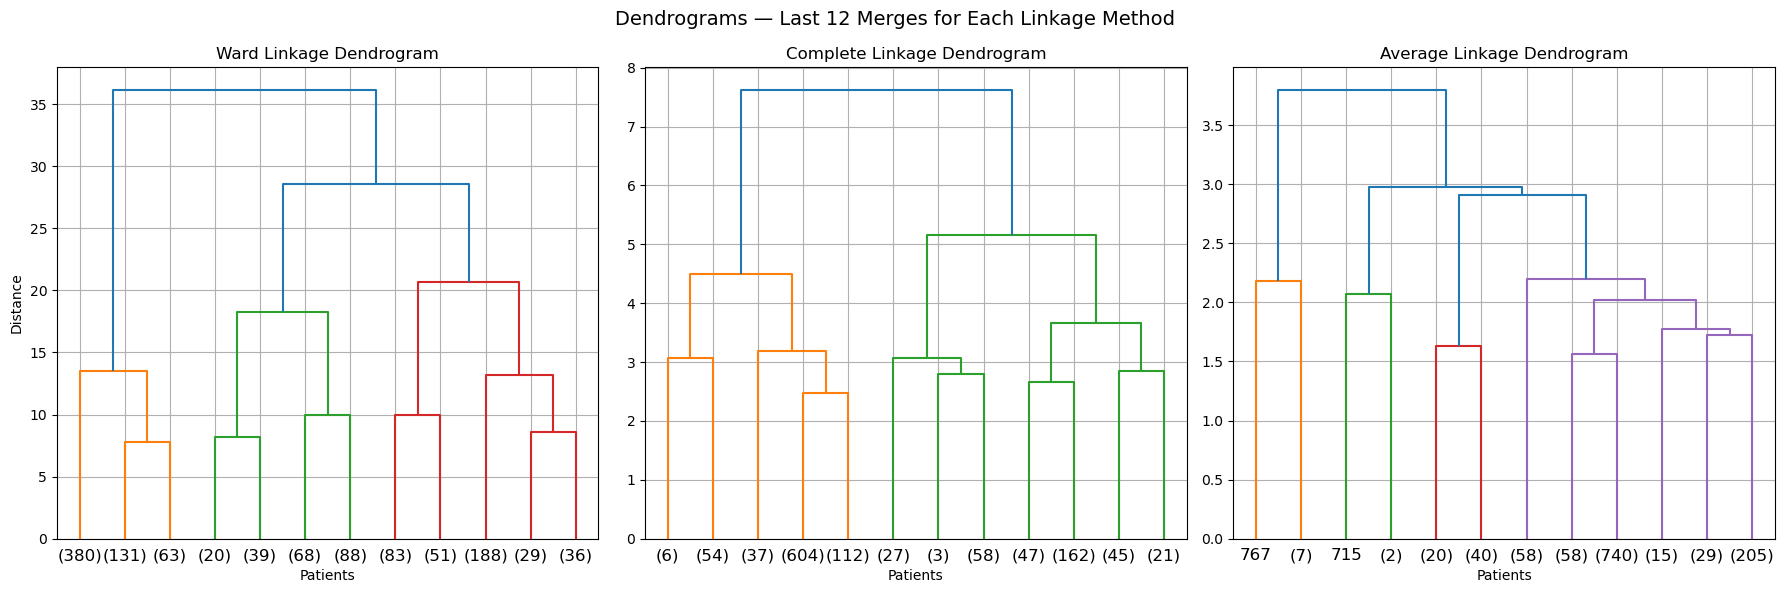

In [115]:
from scipy.cluster.hierarchy import linkage,dendrogram
# Build linkage matrices for all three methods
ward     = linkage(X, method='ward')
complete = linkage(X, method='complete')
average  = linkage(X, method='average')

# Plot dendrograms — we show only the last 20 merges to keep it readable
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dendrogram(ward,     ax=axes[0], truncate_mode='lastp', p=12,
           color_threshold=0.7 * max(ward[:, 2]))
axes[0].set_title('Ward Linkage Dendrogram',     fontsize=12)
axes[0].set_xlabel('Patients')
axes[0].set_ylabel('Distance')

dendrogram(complete, ax=axes[1], truncate_mode='lastp', p=12,
           color_threshold=0.7 * max(complete[:, 2]))
axes[1].set_title('Complete Linkage Dendrogram', fontsize=12)
axes[1].set_xlabel('Patients')

dendrogram(average,  ax=axes[2], truncate_mode='lastp', p=12,
           color_threshold=0.7 * max(average[:, 2]))
axes[2].set_title('Average Linkage Dendrogram',  fontsize=12)
axes[2].set_xlabel('Patients')

plt.suptitle('Dendrograms — Last 12 Merges for Each Linkage Method', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 7 — Fuzzy Inference System

In [116]:
X_unscaled = df_unscaled.drop(columns=['cardio','age', 'gender', 'height', 'weight', 'ap_lo','smoke', 'alco', 'active', 'bmi'])
X_unscaled.head()

,ap_hi,cholesterol,gluc
0,140,2,1
1,160,1,1
2,130,1,1
3,120,1,1
4,120,1,1


In [117]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [118]:
#define antecedent (inputs)
ap_hi = ctrl.Antecedent(np.arange(80, 251, 1), 'ap_hi')
cholesterol = ctrl.Antecedent(np.arange(1, 4, 1), 'cholesterol')
gluc = ctrl.Antecedent(np.arange(1, 4, 1), 'gluc')

In [119]:
#define consequent (output)
cardio_risk = ctrl.Consequent(np.arange(0, 101, 1), 'cardio_risk')

In [120]:
# define fuzzy membership functions
ap_hi["low"] = fuzz.trapmf(ap_hi.universe, [50, 50, 115, 125])
ap_hi["normal"] = fuzz.trimf(ap_hi.universe, [120, 140, 160])
ap_hi["high"] = fuzz.trapmf(ap_hi.universe, [155, 175, 250, 250])


cholesterol["normal"] = fuzz.trimf(cholesterol.universe, [1, 1, 2])
cholesterol["above_normal"] = fuzz.trimf(cholesterol.universe, [1, 2, 3])
cholesterol["well_above_normal"] = fuzz.trimf(cholesterol.universe, [2, 3, 3])


gluc["normal"] = fuzz.trimf(gluc.universe, [1, 1, 2])
gluc["above_normal"] = fuzz.trimf(gluc.universe, [1, 2, 3])
gluc["well_above_normal"] = fuzz.trimf(gluc.universe, [2, 3, 3])


cardio_risk["low"] = fuzz.trimf(cardio_risk.universe, [0, 20, 50])
cardio_risk["medium"] = fuzz.trimf(cardio_risk.universe, [40, 60, 80])
cardio_risk["high"] = fuzz.trimf(cardio_risk.universe, [70, 90, 100])

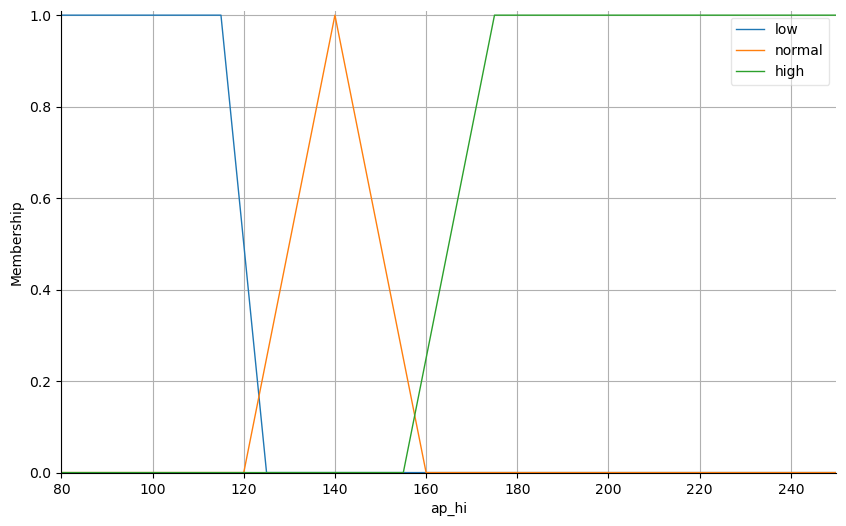

In [121]:
ap_hi.view()

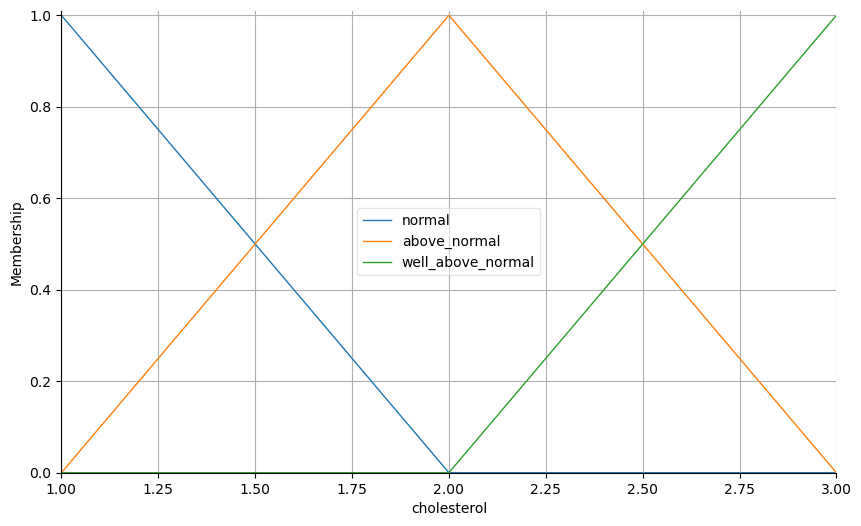

In [122]:
cholesterol.view()

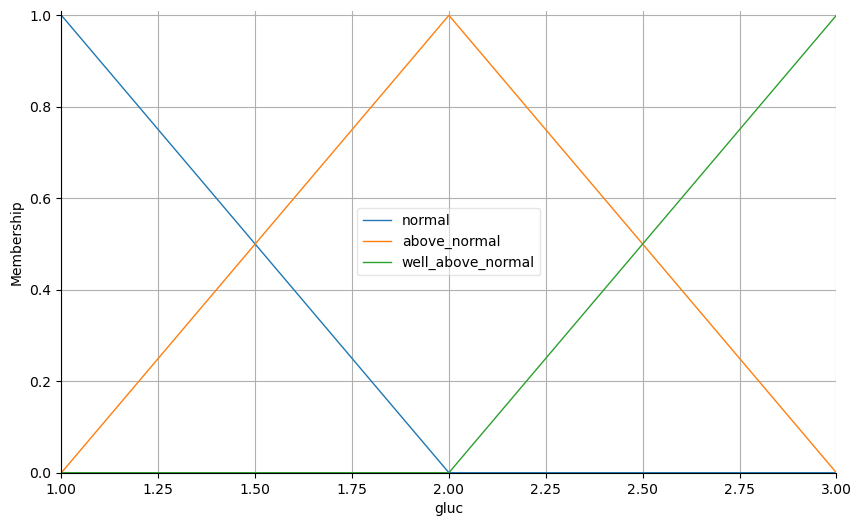

In [123]:
gluc.view()

In [124]:
rules = [
    # High ap_hi
    ctrl.Rule(ap_hi['high'] & cholesterol['well_above_normal'] & gluc['well_above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['well_above_normal'] & gluc['above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['well_above_normal'] & gluc['normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['above_normal'] & gluc['well_above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['above_normal'] & gluc['above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['above_normal'] & gluc['normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['normal'] & gluc['well_above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['normal'] & gluc['above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['high'] & cholesterol['normal'] & gluc['normal'], cardio_risk['high']),
    # Normal ap_hi
    ctrl.Rule(ap_hi['normal'] & cholesterol['well_above_normal'] & gluc['well_above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['well_above_normal'] & gluc['above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['well_above_normal'] & gluc['normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['above_normal'] & gluc['well_above_normal'], cardio_risk['high']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['above_normal'] & gluc['above_normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['above_normal'] & gluc['normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['normal'] & gluc['well_above_normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['normal'] & gluc['above_normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['normal'] & cholesterol['normal'] & gluc['normal'], cardio_risk['low']),
    # Low ap_hi
    ctrl.Rule(ap_hi['low'] & cholesterol['well_above_normal'] & gluc['well_above_normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['low'] & cholesterol['well_above_normal'] & gluc['above_normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['low'] & cholesterol['well_above_normal'] & gluc['normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['low'] & cholesterol['above_normal'] & gluc['well_above_normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['low'] & cholesterol['above_normal'] & gluc['above_normal'], cardio_risk['medium']),
    ctrl.Rule(ap_hi['low'] & cholesterol['above_normal'] & gluc['normal'], cardio_risk['low']),
    ctrl.Rule(ap_hi['low'] & cholesterol['normal'] & gluc['well_above_normal'], cardio_risk['low']),
    ctrl.Rule(ap_hi['low'] & cholesterol['normal'] & gluc['above_normal'], cardio_risk['low']),
    ctrl.Rule(ap_hi['low'] & cholesterol['normal'] & gluc['normal'], cardio_risk['low'])
]

In [125]:
# create fuzzy control system

cardio_ctrl_system = ctrl.ControlSystem(rules)

In [126]:
# create fuzzy simulator
cardio_simulator = ctrl.ControlSystemSimulation(cardio_ctrl_system)

In [127]:
def calculate_cardio_risk(row):
    cardio_simulator.input['ap_hi'] = row['ap_hi']
    cardio_simulator.input['cholesterol'] = row['cholesterol']
    cardio_simulator.input['gluc'] = row['gluc']
    
    try:
        cardio_simulator.compute()
        return cardio_simulator.output['cardio_risk']
    
    except:
        return np.nan  # return NaN if computation fails


In [128]:
X_unscaled['cardio_risk'] = X_unscaled.apply(calculate_cardio_risk, axis=1)

print(X_unscaled[['ap_hi', 'cholesterol', 'gluc', 'cardio_risk']].head())

   ap_hi  cholesterol  gluc  cardio_risk
0    140            2     1    60.000000
1    160            1     1    85.595238
2    130            1     1    23.888889
3    120            1     1    23.888889
4    120            1     1    23.888889


In [129]:
X_unscaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ap_hi        1176 non-null   int64  
 1   cholesterol  1176 non-null   int64  
 2   gluc         1176 non-null   int64  
 3   cardio_risk  1176 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 36.9 KB


In [130]:
X_unscaled.describe()

,ap_hi,cholesterol,gluc,cardio_risk
count,1176.000000,1176.000000,1176.000000,1176.000000
mean,126.546769,1.342687,1.194728,35.480759
std,17.203499,0.664541,0.541399,21.359737
min,70.000000,1.000000,1.000000,23.333333
25%,120.000000,1.000000,1.000000,23.333333
50%,120.000000,1.000000,1.000000,23.888889
75%,140.000000,1.000000,1.000000,60.000000
max,200.000000,3.000000,3.000000,86.666667


In [131]:
X_unscaled.head()

,ap_hi,cholesterol,gluc,cardio_risk
0,140,2,1,60.000000
1,160,1,1,85.595238
2,130,1,1,23.888889
3,120,1,1,23.888889
4,120,1,1,23.888889


In [132]:
cardio_simulator.input['ap_hi'] = 140
cardio_simulator.input['cholesterol'] = 2
cardio_simulator.input['gluc'] = 1

cardio_simulator.compute()
example_value = cardio_simulator.output["cardio_risk"]
print(example_value)

60.00000000000002


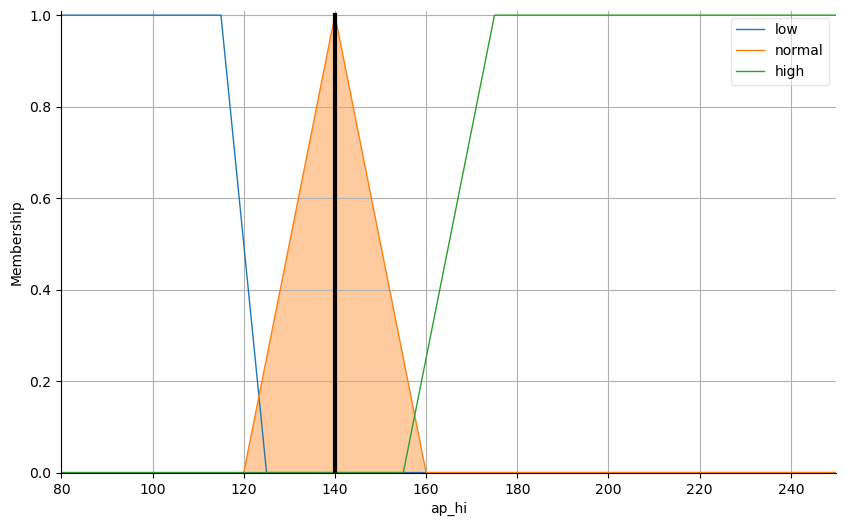

In [133]:
ap_hi.view(cardio_simulator)

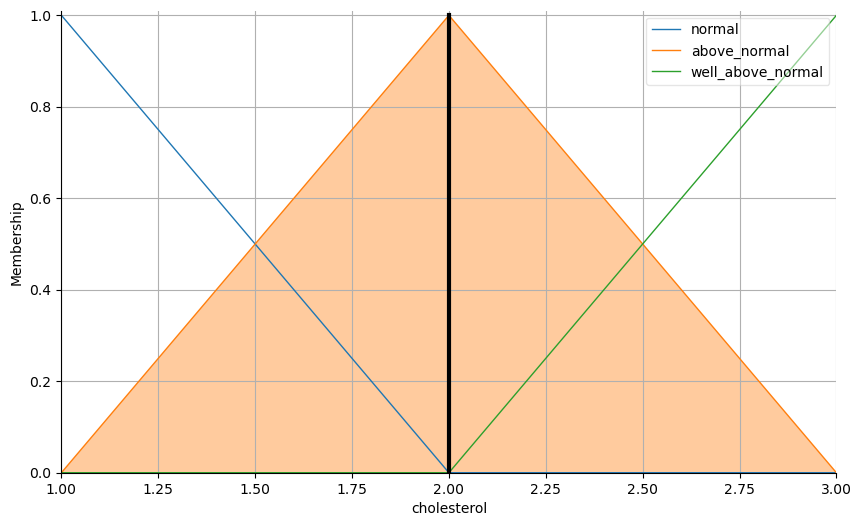

In [134]:
cholesterol.view(cardio_simulator)

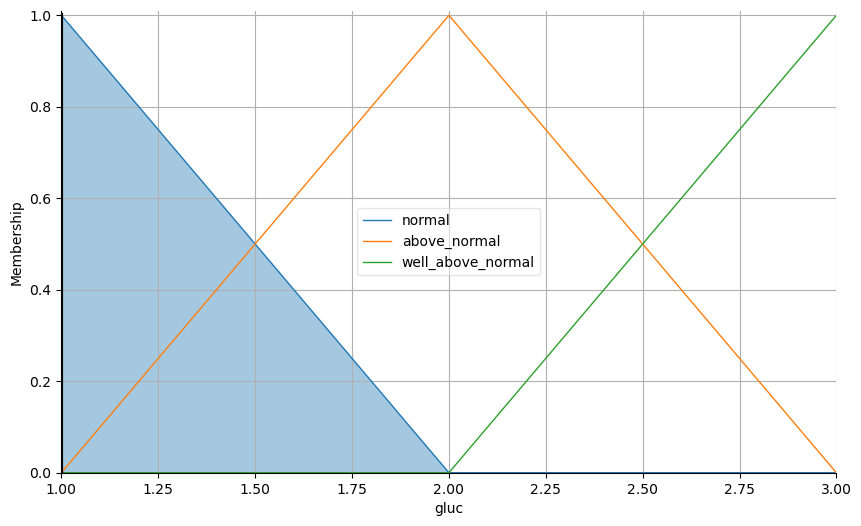

In [135]:
gluc.view(cardio_simulator)

---
## Section 8 — System Implementation

This function integrates all three systems built in this project:

| Step | System | What it does |
|---|---|---|
| 1 | **Preprocessing** | Age conversion, BMI, gender encoding, StandardScaler |
| 2 | **K-Medoids Clustering** | Assigns the patient to the nearest cluster |
| 3 | **Fuzzy Inference System** | Computes a 0–100 cardiovascular risk score |
| 4 | **Output** | Combines both signals → final recommendation |

```


In [ ]:
from IPython.display import display, Markdown

def cardio_risk_pipeline(new_patient_dict, scaler, km,
                         cardio_simulator, cluster_profiles):
   
    print("=" * 60)
    print("  CARDIOVASCULAR DISEASE RISK ASSESSMENT PIPELINE")
    print("=" * 60)


    print("\n[Step 1] Preprocessing patient record...")

    patient_df = pd.DataFrame([new_patient_dict])

    # Convert age from days to years if needed (>1000 = still in days)
    if patient_df['age'].iloc[0] > 1000:
        patient_df['age'] = (patient_df['age'] / 365).round(1)

    # Encode gender: 1 (Female) → 0,  2 (Male) → 1
    patient_df['gender'] = patient_df['gender'].map({1: 0, 2: 1})

    # Compute BMI
    patient_df['bmi'] = (
        patient_df['weight'] / ((patient_df['height'] / 100) ** 2)
    ).round(2)

    # Scale continuous features 
    cols_to_scale = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
    patient_scaled = patient_df.copy()
    patient_scaled[cols_to_scale] = scaler.transform(patient_df[cols_to_scale])

    age_yrs = patient_df['age'].iloc[0]
    bmi_val = patient_df['bmi'].iloc[0]
    bmi_cat = ("Underweight" if bmi_val < 18.5 else
               "Normal"      if bmi_val < 25   else
               "Overweight"  if bmi_val < 30   else "Obese")

    print(f"  Age   : {age_yrs:.1f} years")
    print(f"  BMI   : {bmi_val:.1f}  ({bmi_cat})")
    print(f"  BP    : {new_patient_dict['ap_hi']}/{new_patient_dict['ap_lo']} mmHg")


    print("\n[Step 2] Assigning patient to a cluster (K-Medoids)...")

    # Use the same features the model was trained on (exclude 'cardio')
    cluster_features = [c for c in patient_scaled.columns
                        if c != 'cardio']
    X_cluster    = patient_scaled[cluster_features].values
    cluster_label = int(km.predict(X_cluster)[0])

    # Determine cluster risk from the disease rate in cluster_profiles
    cardio_rate = cluster_profiles.loc[cluster_label, 'cardio'] * 100

    if cardio_rate >= 60:
        cluster_desc = "High-Risk Group"
    elif cardio_rate >= 40:
        cluster_desc = "Moderate-Risk Group"
    else:
        cluster_desc = "Low-Risk Group"

    print(f"  Assigned to Cluster {cluster_label} → {cluster_desc}")
    print(f"  ({cardio_rate:.1f}% of patients in this cluster have cardiovascular disease)")

 
    print("\n[Step 3] Running Fuzzy Inference System...")

    # Feed patient values into the fuzzy simulator
    ap_hi_val = float(np.clip(new_patient_dict['ap_hi'],       80,  250))
    chol_val  = float(np.clip(new_patient_dict['cholesterol'],  1,    3))
    gluc_val  = float(np.clip(new_patient_dict['gluc'],         1,    3))

    cardio_simulator.input['ap_hi']       = ap_hi_val
    cardio_simulator.input['cholesterol'] = chol_val
    cardio_simulator.input['gluc']        = gluc_val

    try:
        cardio_simulator.compute()
        fuzzy_score = cardio_simulator.output['cardio_risk']   # 0 – 100
    except Exception:
        # Fallback if the fuzzy engine cannot compute (edge-case inputs)
        fuzzy_score = 50.0

    # Normalise to 0-1 for the recommendation threshold
    fuzzy_score_norm = fuzzy_score / 100.0

    # Risk label
    if fuzzy_score >= 65:
        risk_level = "High"
    elif fuzzy_score >= 35:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    # Visual bar
    filled  = int(fuzzy_score / 100 * 30)
    bar     = "█" * filled + "░" * (30 - filled)
    print(f"  Fuzzy Risk Score : {fuzzy_score:.1f} / 100  → {risk_level} Risk")
    print(f"  [{bar}]")

    # final assessment
    print("\n" + "=" * 60)
    display(Markdown("###  Final Clinical Assessment"))

    print(f"  • K-Medoids Cluster    : {cluster_label} → {cluster_desc}")
    print(f"  • Fuzzy Risk Score     : {fuzzy_score:.1f}/100  ({risk_level} Risk)")

    # Recommendation driven by fuzzy score + cluster risk together
    high_signals = sum([
        fuzzy_score >= 65,                # fuzzy says high
        cardio_rate >= 60,               # cluster is high-risk
        new_patient_dict['ap_hi'] >= 140 # hypertension
    ])

    if high_signals >= 2 or fuzzy_score >= 75:
        recommendation = " HIGH RISK — Urgent medical consultation recommended."
    elif fuzzy_score >= 35 or cardio_rate >= 40:
        recommendation = " MODERATE RISK — Lifestyle changes + regular monitoring."
    else:
        recommendation = " LOW RISK — Maintain healthy lifestyle & routine check-ups."

    print(f"  • Recommendation       : {recommendation}")

    # Additional flags
    print("\n  Clinical Flags:")
    flags = []
    if new_patient_dict['ap_hi'] >= 140:
        flags.append("   Hypertension detected (systolic ≥ 140 mmHg)")
    if bmi_val >= 30:
        flags.append("   Obesity detected (BMI ≥ 30)")
    if new_patient_dict['cholesterol'] == 3:
        flags.append("   Cholesterol well above normal")
    if new_patient_dict['gluc'] == 3:
        flags.append("   Glucose well above normal — diabetes screening advised")
    if new_patient_dict['smoke']:
        flags.append("   Smoker — cessation strongly advised")
    if not new_patient_dict['active']:
        flags.append("   Sedentary lifestyle — increase physical activity")
    if not flags:
        flags.append("  No immediate clinical flags detected")
    for f in flags:
        print(f)

    print("=" * 60)

    return {
        'cluster'        : cluster_label,
        'cluster_desc'   : cluster_desc,
        'fuzzy_score'    : round(fuzzy_score, 2),
        'risk_level'     : risk_level,
        'recommendation' : recommendation
    }


#  TEST THE PIPELINE — Example Patient

new_patient = {
    'age'        : 21770,  # days → will be converted to ~59.6 years
    'gender'     : 1,      # Female
    'height'     : 165,
    'weight'     : 92.0,
    'ap_hi'      : 155,
    'ap_lo'      : 92,
    'cholesterol': 2,      # Above Normal
    'gluc'       : 1,      # Normal
    'smoke'      : 0,
    'alco'       : 0,
    'active'     : 1
}

# Call the pipeline 
result = cardio_risk_pipeline(
    new_patient_dict  = new_patient,
    scaler            = scaler,          
    km                = best_model,      
    cardio_simulator  = cardio_simulator,
    cluster_profiles  = cluster_profiles 
)

print("\nReturned dictionary:", result)


  CARDIOVASCULAR DISEASE RISK ASSESSMENT PIPELINE

[Step 1] Preprocessing patient record...
  Age   : 59.6 years
  BMI   : 33.8  (Obese)
  BP    : 155/92 mmHg

[Step 2] Assigning patient to a cluster (K-Medoids)...
  Assigned to Cluster 1 → High-Risk Group
  (79.0% of patients in this cluster have cardiovascular disease)

[Step 3] Running Fuzzy Inference System...
  Fuzzy Risk Score : 60.0 / 100  → Medium Risk
  [██████████████████░░░░░░░░░░░░]



###  Final Clinical Assessment

  • K-Medoids Cluster    : 1 → High-Risk Group
  • Fuzzy Risk Score     : 60.0/100  (Medium Risk)
  • Recommendation       :  HIGH RISK — Urgent medical consultation recommended.

  Clinical Flags:
  ⚕  Hypertension detected (systolic ≥ 140 mmHg)
  ⚕  Obesity detected (BMI ≥ 30)

Returned dictionary: {'cluster': 1, 'cluster_desc': 'High-Risk Group', 'fuzzy_score': np.float64(60.0), 'risk_level': 'Medium', 'recommendation': ' HIGH RISK — Urgent medical consultation recommended.'}
